# Milestone 3 - Modelação e Avaliação (Objetivo 1)

Neste notebook é desenvolvida uma abordagem de aprendizagem supervisionada com o objetivo de prever a saída de colaboradores (*Attrition*), com base nas variáveis relevantes do dataset IBM HR Analytics Employee Attrition & Performance.

Esta etapa enquadra-se nas fases de *Modelling* e *Evaluation* da metodologia CRISP-DM, permitindo comparar diferentes algoritmos de classificação supervisionada para identificar os modelos mais eficazes na deteção de colaboradores com maior propensão ao abandono.

Ao contrário da abordagem de clustering desenvolvida no Objetivo 3, esta análise utiliza diretamente a variável alvo (*Attrition*) no processo de aprendizagem, procurando construir modelos capazes de prever o risco de saída de forma robusta, interpretável e generalizável.

## Estrutura da Análise

Foram aplicados e comparados diferentes algoritmos de classificação:

- Baseline: Árvore de Decisão
- Candidato 1: Random Forest
- Candidato 2: Gradient Boosting
- Candidato 3: XGBoost
- Candidato 4: LightGBM
- Candidato 5: CatBoost
- Candidato 6: SVM
- Candidato 7: Árvore de Decisão com Pruning
- Candidato 8: Regressão Logística (baseline linear)
- Candidato 9: Linear Discriminant Analysis (LDA)
- Candidato 10: Naive Bayes (GaussianNB)
- Candidato 11: K-Nearest Neighbors (KNN)
- Candidato 12: Extra Trees
- Candidato 13: Rede Neuronal MLP (sklearn)
- Candidato 14: Rede Neuronal TabNet (pytorch-tabnet)
- Candidato 15: Rede Neuronal Keras (TensorFlow)
- Candidato 16: Keras com Dropout + BatchNormalization
- Candidato 17: GANDALF (pytorch-tabular)
- Candidato 18: FT-Transformer (pytorch-tabular)

## Metodologia

A análise segue os seguintes passos principais:

- Preparação e seleção das variáveis;
- Divisão dos dados em treino e teste com estratificação;
- Normalização dos dados quando aplicável;
- Treino e avaliação dos modelos supervisionados;
- Comparação entre desempenho em treino e teste;
- Identificação de possíveis situações de *overfitting*;
- Otimização de parâmetros (*tuning*) dos modelos selecionados;
- Ajuste de *thresholds* de decisão para melhoria do *Recall* e *F1-Score*;
- Avaliação da robustez e capacidade de generalização;
- Interpretação dos resultados no contexto organizacional.

## Métricas de Avaliação

A qualidade dos modelos é avaliada com base em métricas adequadas ao problema de classificação:

- *Accuracy* → mede a proporção global de classificações corretas;
- *Precision* → mede a proporção de previsões positivas corretas;
- *Recall* → mede a capacidade de identificar colaboradores que efetivamente abandonam a empresa;
- *F1-Score* → equilíbrio entre *Precision* e *Recall*;
- *AUC-ROC* → avalia a capacidade global de separação entre classes.

Dado o contexto do problema, é atribuída especial importância ao *Recall* e ao *F1-Score*, uma vez que a correta identificação de colaboradores em risco de saída é prioritária do ponto de vista da gestão de recursos humanos.

Adicionalmente, é analisada a estabilidade entre treino e teste, garantindo que os modelos apresentam capacidade de generalização e não apenas bom desempenho sobre os dados de treino.

## Objetivo Final

Selecionar o modelo de classificação com melhor equilíbrio entre desempenho estatístico, robustez e interpretabilidade, utilizando-o posteriormente para:

- Construir um índice de risco de *Attrition*;
- Estimar probabilidades individuais de saída;
- Apoiar estratégias de retenção de talento;
- Identificar colaboradores com maior risco de abandono;
- Suportar a tomada de decisão em contexto de gestão de recursos humanos.

*Autores: Luís Figueira, Martim Ferreira e Mateus Afonso*

# Parte I - Importações e Carregamento de Dados

In [1]:
# 1. Importações das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess

libs = ["xgboost", "lightgbm", "catboost"]

for lib in libs:
    subprocess.run(["pip", "install", lib, "-q"], check=True)
    print(f"  {lib} instalado.")

print("\nInstalação concluída.")

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas importadas com sucesso.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

  xgboost instalado.
  lightgbm instalado.
  catboost instalado.

Instalação concluída.
Bibliotecas importadas com sucesso.


In [2]:
# 2. Carregamento do dataset
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Dataset carregado: 1470 linhas, 62 colunas


# Parte II - Comparação de Modelos

## BASELINE - Árvore de Decisão
Modelo baseline com `DecisionTreeClassifier` (parâmetros default).

In [3]:
# 1. Divisão treino e teste
cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]

cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

TARGET = "Attrition_bin"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=42
)

print(f"Features utilizadas: {X.shape[1]}")
print(f"Treino: {X_train.shape[0]} observacoes  ({y_train.mean()*100:.1f}% Yes)")
print(f"Teste:  {X_test.shape[0]} observacoes  ({y_test.mean()*100:.1f}% Yes)")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Features utilizadas: 53
Treino: 955 observacoes  (16.1% Yes)
Teste:  515 observacoes  (16.1% Yes)


In [4]:
# 2. Treino do modelo
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf.get_depth()}")
print(f"  Numero de folhas:       {clf.get_n_leaves()}")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Modelo treinado.
  Profundidade da arvore: 15
  Numero de folhas:       113


In [5]:
# 3. Métricas no treino
y_pred_train  = clf.predict(X_train)
y_proba_train = clf.predict_proba(X_train)[:, 1]

print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [6]:
# 4. Métricas no teste
y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]

print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — TESTE =====
  F1-Score:  0.2483
  Precision: 0.2903
  Recall:    0.2169
  AUC-ROC:   0.5575

              precision    recall  f1-score   support

  Permaneceu       0.86      0.90      0.88       432
        Saiu       0.29      0.22      0.25        83

    accuracy                           0.79       515
   macro avg       0.57      0.56      0.56       515
weighted avg       0.77      0.79      0.78       515



In [7]:
# 5. Tabela comparativa treino vs teste
resultados = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)

print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.2483,0.2903,0.2169,0.5575



  Diferenca F1 (treino - teste): 0.7517
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


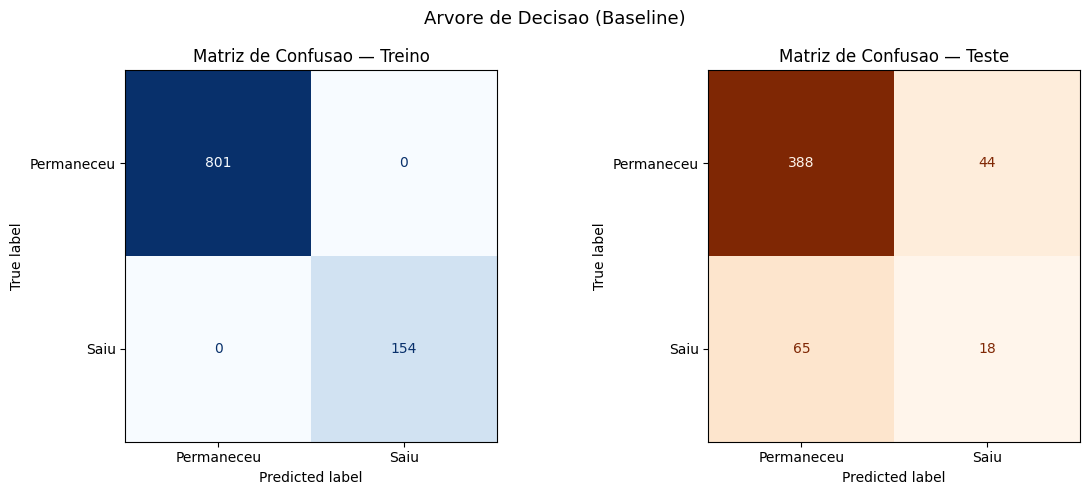

In [8]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_train, y_pred_train),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao (Baseline)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

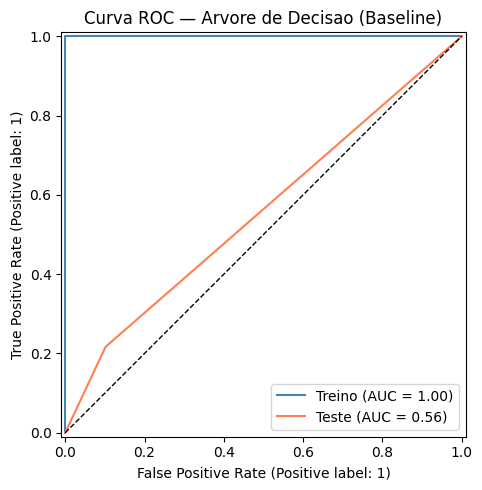

In [9]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore de Decisao (Baseline)")
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

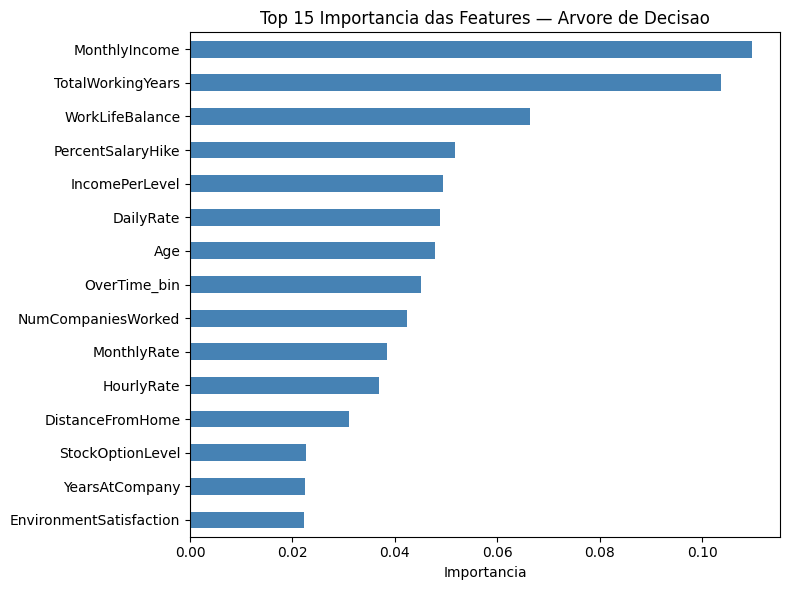

In [10]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore de Decisao")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

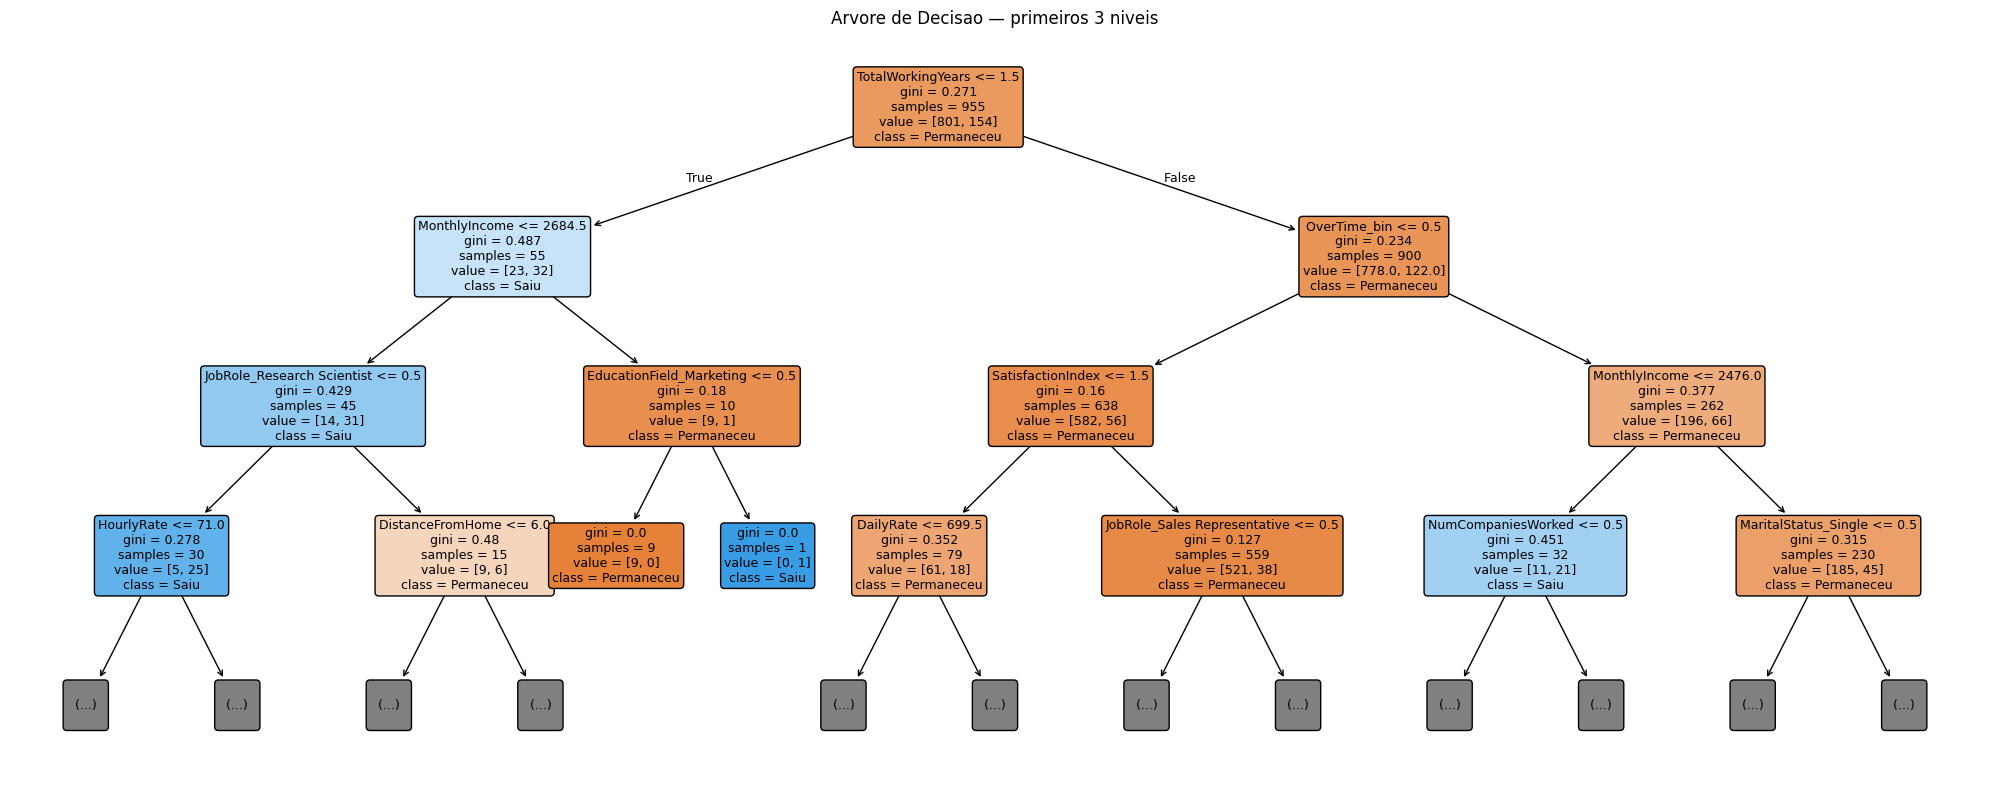

In [11]:
# 9. Visualização — árvore de decisão
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [12]:
# 10. Análise da matriz confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 388  OK
  FP — Permaneceu, previsto Saiu:       44  Erro
  FN — Saiu, previsto Permaneceu:       65  Erro (critico)
  TP — Saiu, previsto Saiu:             18  OK

  O modelo falhou em detetar 65 saidas reais (Falsos Negativos).


In [13]:
# 11. RESUMO FINAL
baseline_f1 = f1_score(y_test, y_pred_test)

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao (parâmetros default)")
print(f"  Features:          {X.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (nao necessaria)")
print(f"  Balanceamento:     Nenhum (baseline simples)")
print(f"  Metrica principal: F1-Score")
print(f"  Profundidade:      {clf.get_depth()} niveis")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {baseline_f1:.4f}")
print()
print("  Referencial minimo para os modelos candidatos.")
print("=" * 55)
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

RESUMO — BASELINE
  Algoritmo:         Arvore de Decisao (parâmetros default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (nao necessaria)
  Balanceamento:     Nenhum (baseline simples)
  Metrica principal: F1-Score
  Profundidade:      15 niveis

  F1 treino: 1.0000
  F1 teste:  0.2483

  Referencial minimo para os modelos candidatos.


## CANDIDATO 1 - Random Forest

In [14]:
# 1. Importações
from sklearn.ensemble import RandomForestClassifier
print("Bibliotecas importadas com sucesso.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Bibliotecas importadas com sucesso.


In [15]:
# 2. Treino do modelo
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)
print("Modelo treinado.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Modelo treinado.


In [16]:
# 3. Métricas no treino
y_pred_train  = clf_rf.predict(X_train)
y_proba_train = clf_rf.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [17]:
# 4. Métricas no teste
y_pred_test  = clf_rf.predict(X_test)
y_proba_test = clf_rf.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — TESTE =====
  F1-Score:  0.2157
  Precision: 0.5789
  Recall:    0.1325
  AUC-ROC:   0.7806

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       432
        Saiu       0.58      0.13      0.22        83

    accuracy                           0.84       515
   macro avg       0.72      0.56      0.56       515
weighted avg       0.81      0.84      0.80       515



In [18]:
# 5. Tabela comparativa treino vs teste
resultados_rf = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_rf)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
# Autor: Figueira, L.

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.2157,0.5789,0.1325,0.7806



  Diferenca F1 (treino - teste): 0.7843
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


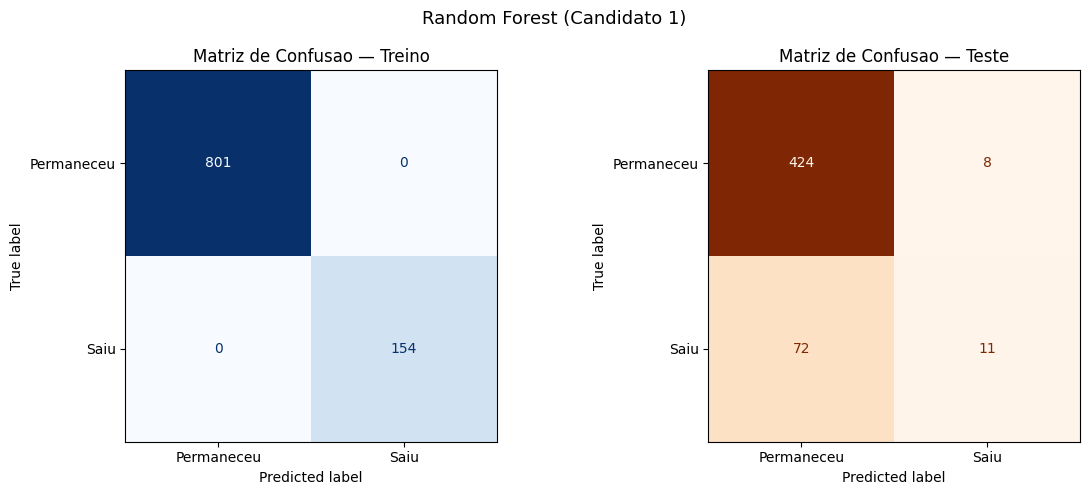

In [19]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Random Forest (Candidato 1)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

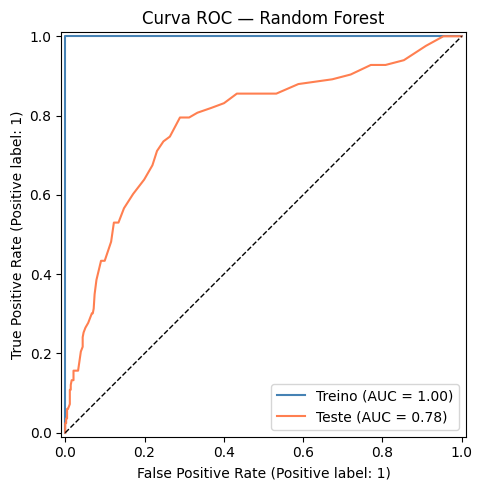

In [20]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Random Forest")
plt.tight_layout()
plt.savefig("roc_curve_rf.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

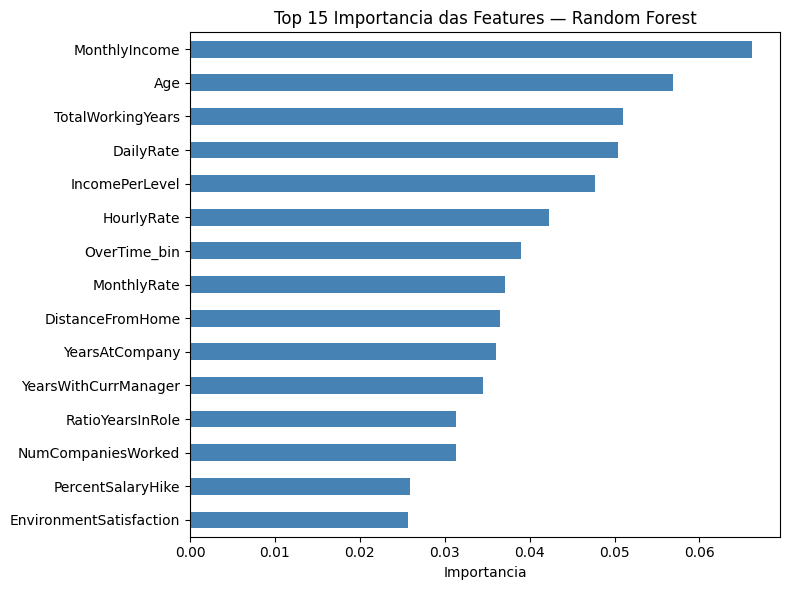

In [21]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

In [22]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")
# Autor: Figueira, L.

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 424  OK
  FP — Permaneceu, previsto Saiu:       8  Erro
  FN — Saiu, previsto Permaneceu:       72  Erro (critico)
  TP — Saiu, previsto Saiu:             11  OK

  O modelo falhou em detetar 72 saidas reais (Falsos Negativos).


In [23]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 1")
print("=" * 55)
print(f"  Algoritmo:         Random Forest")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 1
  Algoritmo:         Random Forest
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.2157
  Baseline:  0.2483
  Melhoria:  -0.0326


## CANDIDATO 2 - Gradient Boosting

In [24]:
# 1. Importações
from sklearn.ensemble import GradientBoostingClassifier
print("Bibliotecas importadas com sucesso.")
# Autor: Figueira, L.

Bibliotecas importadas com sucesso.


In [25]:
# 2. Treino do modelo
clf_gb = GradientBoostingClassifier(random_state=42)
clf_gb.fit(X_train, y_train)
print("Modelo treinado.")
# Autor: Figueira, L.

Modelo treinado.


In [26]:
# 3. Métricas no treino
y_pred_train  = clf_gb.predict(X_train)
y_proba_train = clf_gb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TREINO =====
  F1-Score:  0.9039
  Precision: 1.0000
  Recall:    0.8247
  AUC-ROC:   0.9966

              precision    recall  f1-score   support

  Permaneceu       0.97      1.00      0.98       801
        Saiu       1.00      0.82      0.90       154

    accuracy                           0.97       955
   macro avg       0.98      0.91      0.94       955
weighted avg       0.97      0.97      0.97       955



In [27]:
# 4. Métricas no teste
y_pred_test  = clf_gb.predict(X_test)
y_proba_test = clf_gb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TESTE =====
  F1-Score:  0.3559
  Precision: 0.6000
  Recall:    0.2530
  AUC-ROC:   0.7791

              precision    recall  f1-score   support

  Permaneceu       0.87      0.97      0.92       432
        Saiu       0.60      0.25      0.36        83

    accuracy                           0.85       515
   macro avg       0.74      0.61      0.64       515
weighted avg       0.83      0.85      0.83       515



In [28]:
# 5. Tabela comparativa treino vs teste
resultados_gb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_gb)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
# Autor: Figueira, L.

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9039,1.0,0.8247,0.9966
1,Teste,0.3559,0.6,0.2530,0.7791



  Diferenca F1 (treino - teste): 0.5480
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


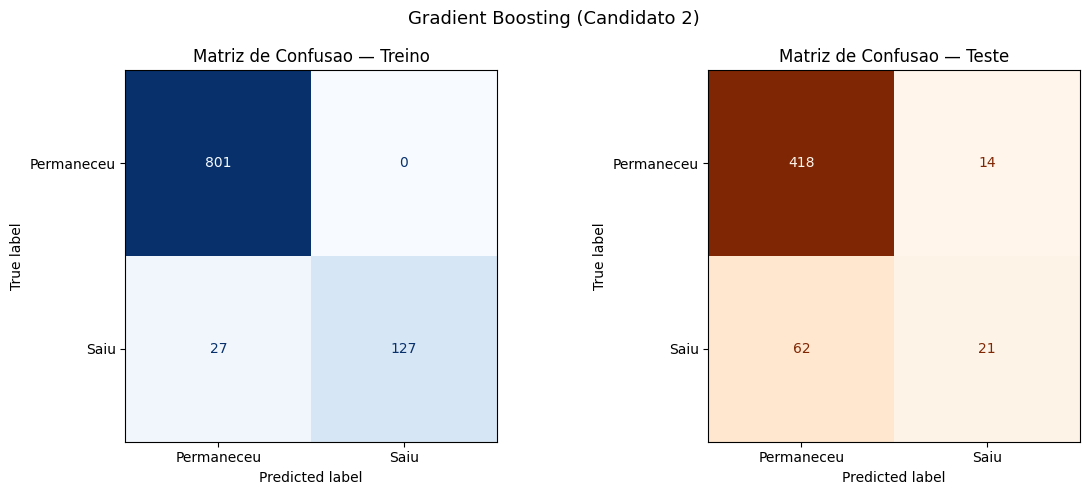

In [29]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Gradient Boosting (Candidato 2)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_gb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

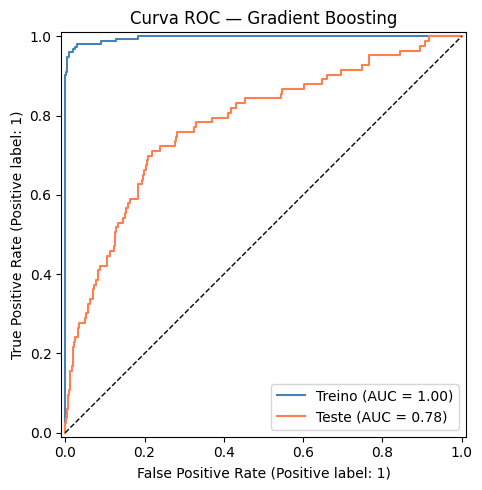

In [30]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Gradient Boosting")
plt.tight_layout()
plt.savefig("roc_curve_gb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

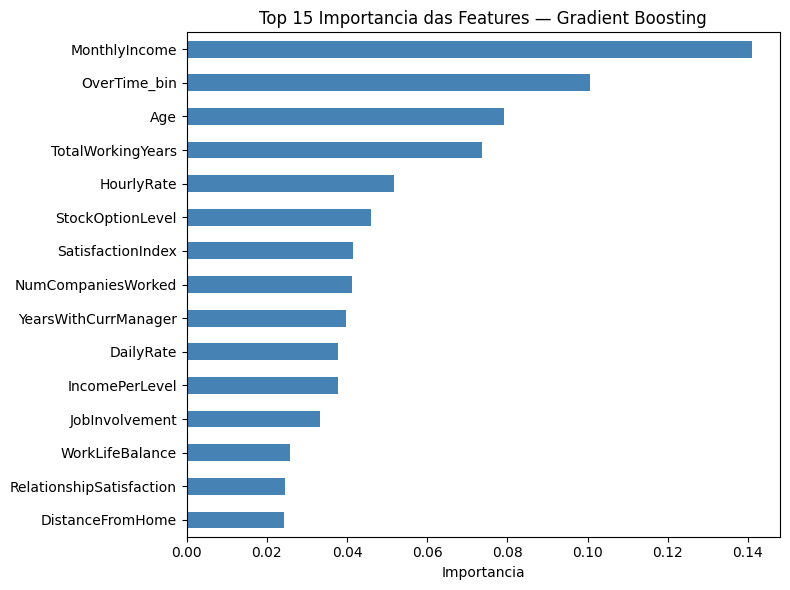

In [31]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Gradient Boosting")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

In [32]:
# 9. Análise da matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")
# Autor: Figueira, L.

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 418  OK
  FP — Permaneceu, previsto Saiu:       14  Erro
  FN — Saiu, previsto Permaneceu:       62  Erro (critico)
  TP — Saiu, previsto Saiu:             21  OK

  O modelo falhou em detetar 62 saidas reais (Falsos Negativos).


In [33]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 2")
print("=" * 55)
print(f"  Algoritmo:         Gradient Boosting")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)
# Autor: Figueira, L.

RESUMO — CANDIDATO 2
  Algoritmo:         Gradient Boosting
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9039
  F1 teste:  0.3559
  Baseline:  0.2483
  Melhoria:  +0.1077


## CANDIDATO 3 - XGBoost

In [34]:
# 1. Importações
from xgboost import XGBClassifier
print("Bibliotecas importadas com sucesso.")
# Autor: Figueira, L.

Bibliotecas importadas com sucesso.


In [35]:
# 2. Treino do modelo
clf_xgb = XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False)
clf_xgb.fit(X_train, y_train)
print("Modelo treinado.")
# Autor: Figueira, L.

Modelo treinado.


In [36]:
# 3. Métricas no treino
y_pred_train  = clf_xgb.predict(X_train)
y_proba_train = clf_xgb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [37]:
# 4. Métricas no teste
y_pred_test  = clf_xgb.predict(X_test)
y_proba_test = clf_xgb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TESTE =====
  F1-Score:  0.3621
  Precision: 0.6364
  Recall:    0.2530
  AUC-ROC:   0.7361

              precision    recall  f1-score   support

  Permaneceu       0.87      0.97      0.92       432
        Saiu       0.64      0.25      0.36        83

    accuracy                           0.86       515
   macro avg       0.75      0.61      0.64       515
weighted avg       0.83      0.86      0.83       515



In [38]:
# 5. Tabela comparativa treino vs teste
resultados_xgb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_xgb)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
# Autor: Figueira, L.

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.0000
1,Teste,0.3621,0.6364,0.253,0.7361



  Diferenca F1 (treino - teste): 0.6379
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


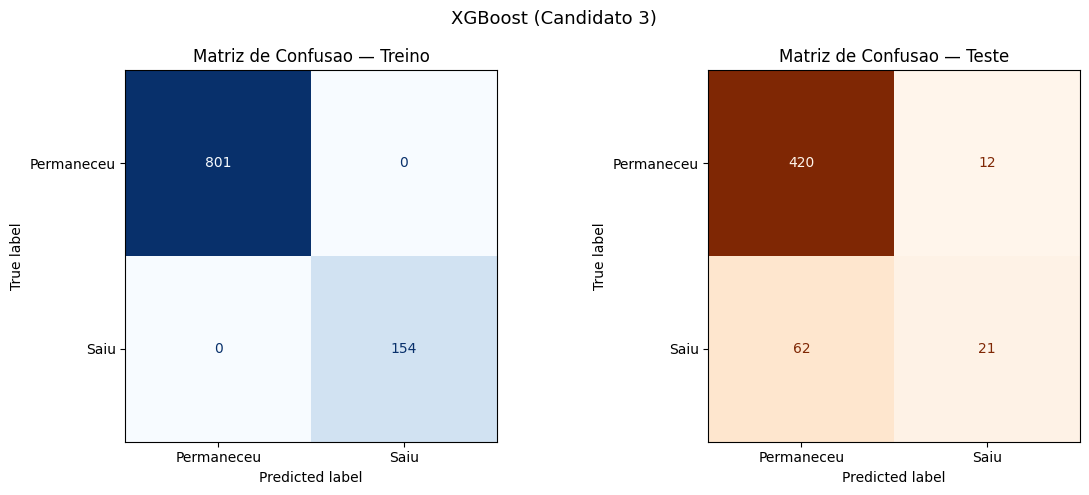

In [39]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("XGBoost (Candidato 3)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

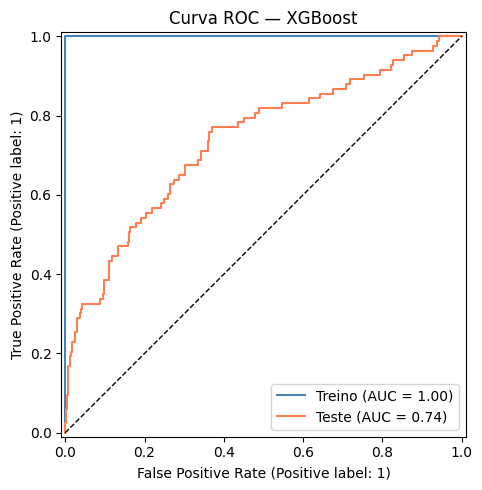

In [40]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — XGBoost")
plt.tight_layout()
plt.savefig("roc_curve_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

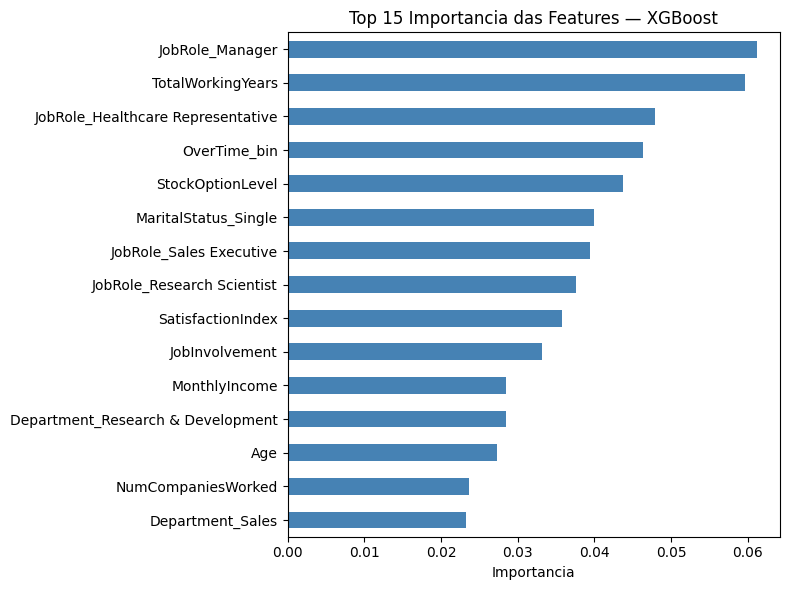

In [41]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — XGBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

In [42]:
# 9. Análise de matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")
# Autor: Figueira, L.

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 420  OK
  FP — Permaneceu, previsto Saiu:       12  Erro
  FN — Saiu, previsto Permaneceu:       62  Erro (critico)
  TP — Saiu, previsto Saiu:             21  OK

  O modelo falhou em detetar 62 saidas reais (Falsos Negativos).


In [43]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 3")
print("=" * 55)
print(f"  Algoritmo:         XGBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)
# Autor: Figueira, L.

RESUMO — CANDIDATO 3
  Algoritmo:         XGBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3621
  Baseline:  0.2483
  Melhoria:  +0.1138


## CANDIDATO 4 - LightGBM

In [44]:
# 1. Importações
from lightgbm import LGBMClassifier
print("Bibliotecas importadas com sucesso.")
# Autor: Figueira, L.

Bibliotecas importadas com sucesso.


In [45]:
# 2. Treino do modelo
clf_lgbm = LGBMClassifier(random_state=42, verbose=-1)
clf_lgbm.fit(X_train, y_train)
print("Modelo treinado.")
# Autor: Figueira, L.

Modelo treinado.


In [46]:
# 3. Métricas no treino
y_pred_train  = clf_lgbm.predict(X_train)
y_proba_train = clf_lgbm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [47]:
# 4. Métricas no teste
y_pred_test  = clf_lgbm.predict(X_test)
y_proba_test = clf_lgbm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))
# Autor: Figueira, L.

===== METRICAS — TESTE =====
  F1-Score:  0.3119
  Precision: 0.6538
  Recall:    0.2048
  AUC-ROC:   0.7578

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.92       432
        Saiu       0.65      0.20      0.31        83

    accuracy                           0.85       515
   macro avg       0.76      0.59      0.62       515
weighted avg       0.83      0.85      0.82       515



In [48]:
# 5. Tabela comparativa treino vs teste
resultados_lgbm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lgbm)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
# Autor: Figueira, L.

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.3119,0.6538,0.2048,0.7578



  Diferenca F1 (treino - teste): 0.6881
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


<function matplotlib.pyplot.show(close=None, block=None)>

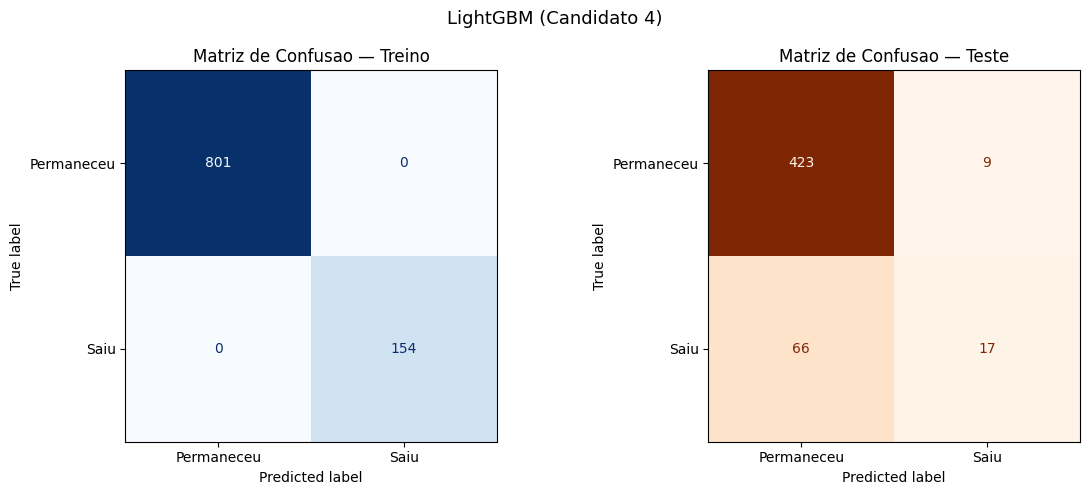

In [49]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LightGBM (Candidato 4)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lgbm.png", dpi=150, bbox_inches="tight")
plt.show
# Autor: Figueira, L.

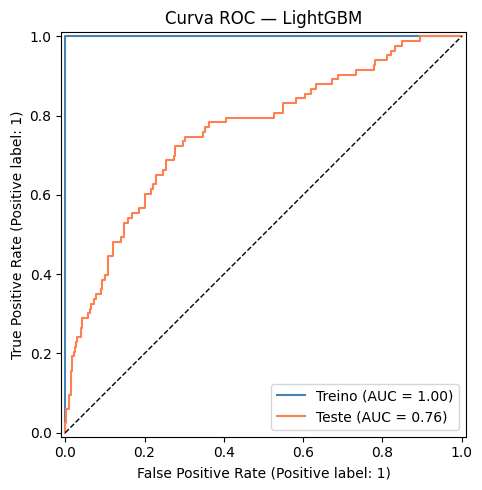

In [50]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LightGBM")
plt.tight_layout()
plt.savefig("roc_curve_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()
# Autor: Figueira, L.

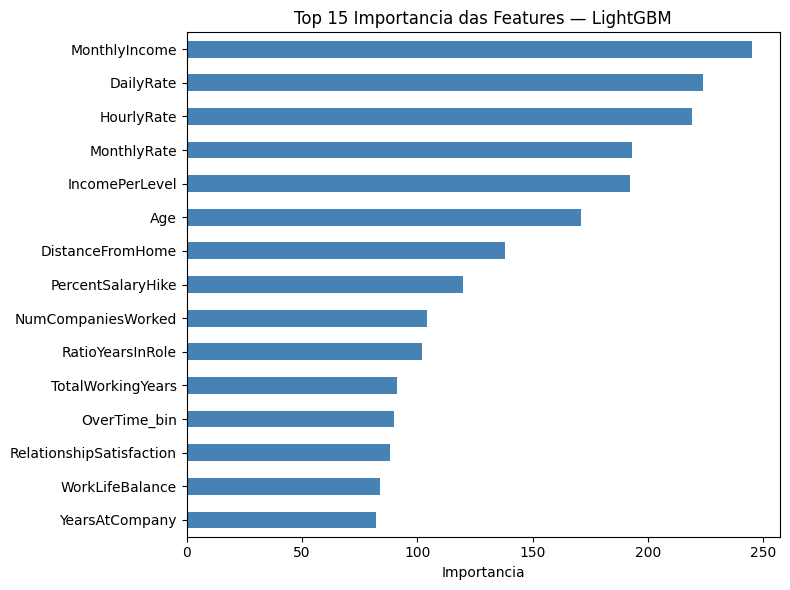

In [51]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — LightGBM")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
# 9. Análise da matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")
# Autor: Figueira, L.

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 423  OK
  FP — Permaneceu, previsto Saiu:       9  Erro
  FN — Saiu, previsto Permaneceu:       66  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 66 saidas reais (Falsos Negativos).


In [53]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 4")
print("=" * 55)
print(f"  Algoritmo:         LightGBM")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)
# Autor: Figueira, L.

RESUMO — CANDIDATO 4
  Algoritmo:         LightGBM
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3119
  Baseline:  0.2483
  Melhoria:  +0.0637


## CANDIDATO 5 - CatBoost

In [54]:
# 1. Importações
from catboost import CatBoostClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [55]:
# 2. Treino do modelo
clf_cat = CatBoostClassifier(random_state=42, verbose=0)
clf_cat.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [56]:
# 3. Métricas no treino
y_pred_train  = clf_cat.predict(X_train)
y_proba_train = clf_cat.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9699
  Precision: 1.0000
  Recall:    0.9416
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       0.99      1.00      0.99       801
        Saiu       1.00      0.94      0.97       154

    accuracy                           0.99       955
   macro avg       0.99      0.97      0.98       955
weighted avg       0.99      0.99      0.99       955



In [57]:
# 4. Métricas no teste
y_pred_test  = clf_cat.predict(X_test)
y_proba_test = clf_cat.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2885
  Precision: 0.7143
  Recall:    0.1807
  AUC-ROC:   0.7994

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       432
        Saiu       0.71      0.18      0.29        83

    accuracy                           0.86       515
   macro avg       0.79      0.58      0.60       515
weighted avg       0.84      0.86      0.82       515



In [58]:
# 5. Tabela comparativa treino vs teste
resultados_cat = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_cat)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9699,1.0000,0.9416,1.0000
1,Teste,0.2885,0.7143,0.1807,0.7994



  Diferenca F1 (treino - teste): 0.6814
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


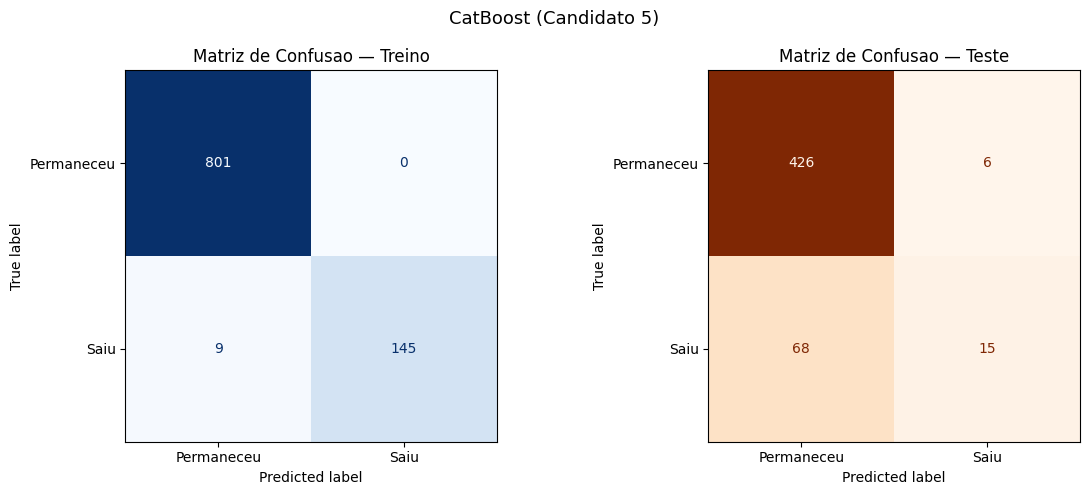

In [59]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("CatBoost (Candidato 5)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_cat.png", dpi=150, bbox_inches="tight")
plt.show()

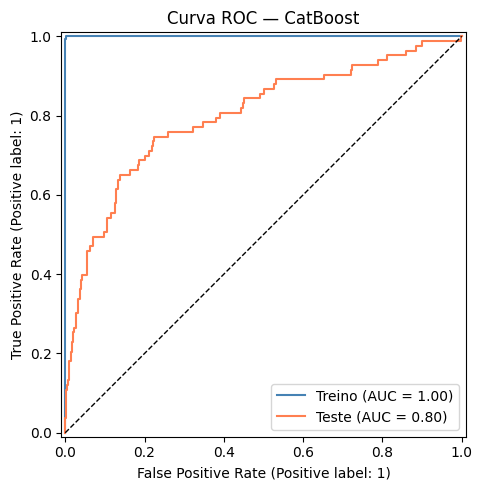

In [60]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — CatBoost")
plt.tight_layout()
plt.savefig("roc_curve_cat.png", dpi=150, bbox_inches="tight")
plt.show()

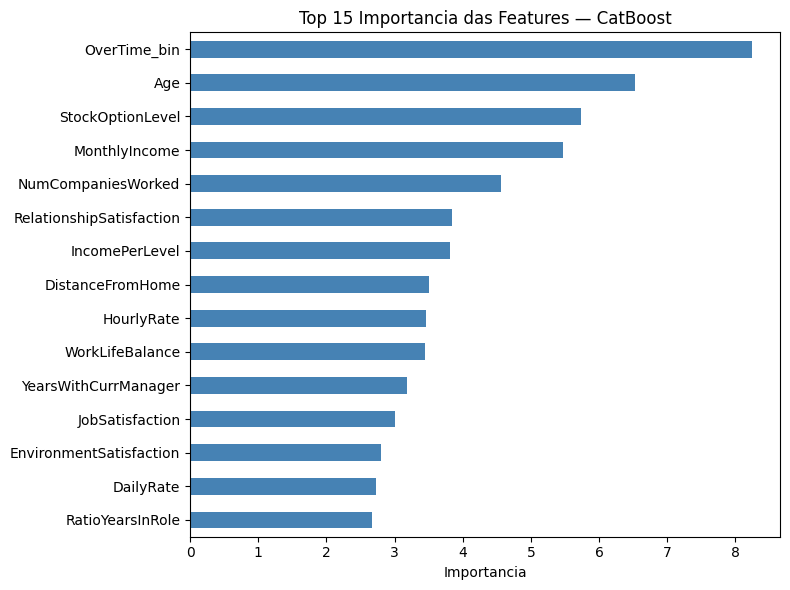

In [61]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_cat.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — CatBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_cat.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# 9. Análise de matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 426  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       68  Erro (critico)
  TP — Saiu, previsto Saiu:             15  OK

  O modelo falhou em detetar 68 saidas reais (Falsos Negativos).


In [63]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 5")
print("=" * 55)
print(f"  Algoritmo:         CatBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 5
  Algoritmo:         CatBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9699
  F1 teste:  0.2885
  Baseline:  0.2483
  Melhoria:  +0.0402


## CANDIDATO 6 - SVM

In [64]:
# 1. Importações
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [65]:
# 2. Treino do modelo
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(probability=True, random_state=42))
])

pipeline_svm.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [66]:
# 3. Métricas no treino
y_pred_train  = pipeline_svm.predict(X_train)
y_proba_train = pipeline_svm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6667
  Precision: 1.0000
  Recall:    0.5000
  AUC-ROC:   0.9685

              precision    recall  f1-score   support

  Permaneceu       0.91      1.00      0.95       801
        Saiu       1.00      0.50      0.67       154

    accuracy                           0.92       955
   macro avg       0.96      0.75      0.81       955
weighted avg       0.93      0.92      0.91       955



In [67]:
# 4. Métricas no teste
y_pred_test  = pipeline_svm.predict(X_test)
y_proba_test = pipeline_svm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2800
  Precision: 0.8235
  Recall:    0.1687
  AUC-ROC:   0.8187

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       432
        Saiu       0.82      0.17      0.28        83

    accuracy                           0.86       515
   macro avg       0.84      0.58      0.60       515
weighted avg       0.86      0.86      0.82       515



In [68]:
# 5. Tabela comparativa treino vs teste
resultados_svm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_svm)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6667,1.0000,0.5000,0.9685
1,Teste,0.2800,0.8235,0.1687,0.8187



  Diferenca F1 (treino - teste): 0.3867
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


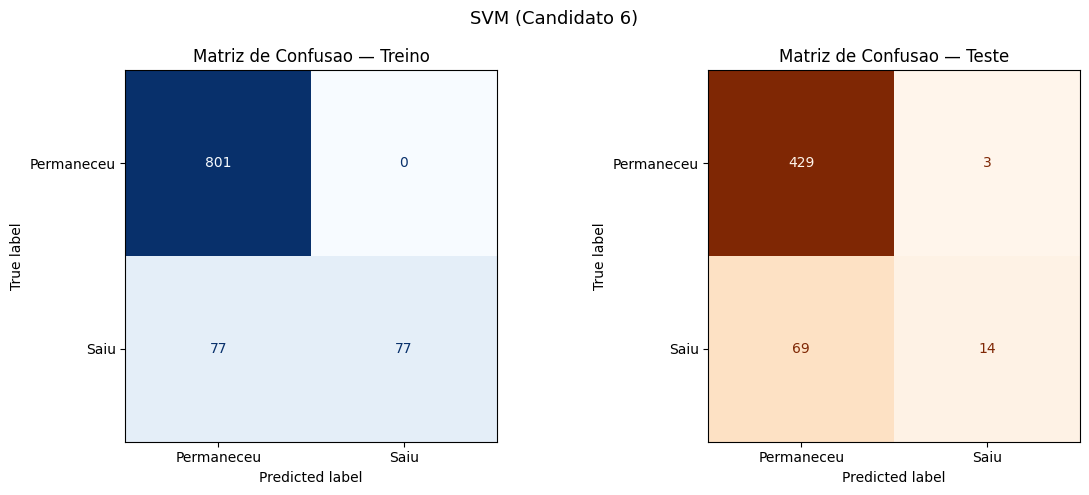

In [69]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("SVM (Candidato 6)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches="tight")
plt.show()

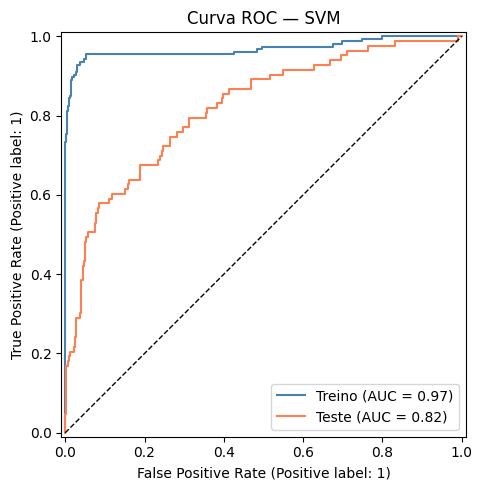

In [70]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — SVM")
plt.tight_layout()
plt.savefig("roc_curve_svm.png", dpi=150, bbox_inches="tight")
plt.show()

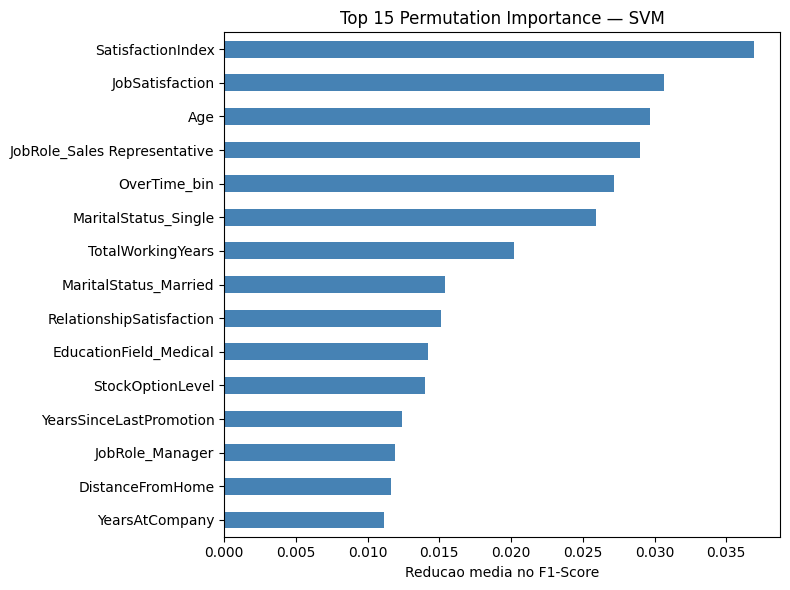

In [71]:
# 8. Visualização 15 atributos mais importantes
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    pipeline_svm, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

feat_imp = pd.Series(perm.importances_mean, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Permutation Importance — SVM")
ax.set_xlabel("Reducao media no F1-Score")
plt.tight_layout()
plt.savefig("feature_importance_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [72]:
# 9. Análise de matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 429  OK
  FP — Permaneceu, previsto Saiu:       3  Erro
  FN — Saiu, previsto Permaneceu:       69  Erro (critico)
  TP — Saiu, previsto Saiu:             14  OK

  O modelo falhou em detetar 69 saidas reais (Falsos Negativos).


In [73]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 6")
print("=" * 55)
print(f"  Algoritmo:         SVM (kernel RBF)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler (obrigatoria para SVM)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 6
  Algoritmo:         SVM (kernel RBF)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler (obrigatoria para SVM)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6667
  F1 teste:  0.2800
  Baseline:  0.2483
  Melhoria:  +0.0317


## CANDIDATO 7 - Árvore de Decisão com Pruning

In [74]:
# 1. Importações
from sklearn.tree import DecisionTreeClassifier, plot_tree
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [75]:
# 2. Treino do modelo
clf_pruned = DecisionTreeClassifier(ccp_alpha=0.005, random_state=42)
clf_pruned.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf_pruned.get_depth()}")
print(f"  Numero de folhas:       {clf_pruned.get_n_leaves()}")
print(f"  ccp_alpha:              {clf_pruned.ccp_alpha}")

Modelo treinado.
  Profundidade da arvore: 4
  Numero de folhas:       6
  ccp_alpha:              0.005


In [76]:
# 3. Métricas no treino
y_pred_train  = clf_pruned.predict(X_train)
y_proba_train = clf_pruned.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4502
  Precision: 0.6753
  Recall:    0.3377
  AUC-ROC:   0.7293

              precision    recall  f1-score   support

  Permaneceu       0.88      0.97      0.92       801
        Saiu       0.68      0.34      0.45       154

    accuracy                           0.87       955
   macro avg       0.78      0.65      0.69       955
weighted avg       0.85      0.87      0.85       955



In [77]:
# 4. Métricas no teste
y_pred_test  = clf_pruned.predict(X_test)
y_proba_test = clf_pruned.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2698
  Precision: 0.3953
  Recall:    0.2048
  AUC-ROC:   0.6919

              precision    recall  f1-score   support

  Permaneceu       0.86      0.94      0.90       432
        Saiu       0.40      0.20      0.27        83

    accuracy                           0.82       515
   macro avg       0.63      0.57      0.58       515
weighted avg       0.79      0.82      0.80       515



In [78]:
# 5. Tabela comparativa treino vs teste
resultados_pruned = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_pruned)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4502,0.6753,0.3377,0.7293
1,Teste,0.2698,0.3953,0.2048,0.6919



  Diferenca F1 (treino - teste): 0.1804
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


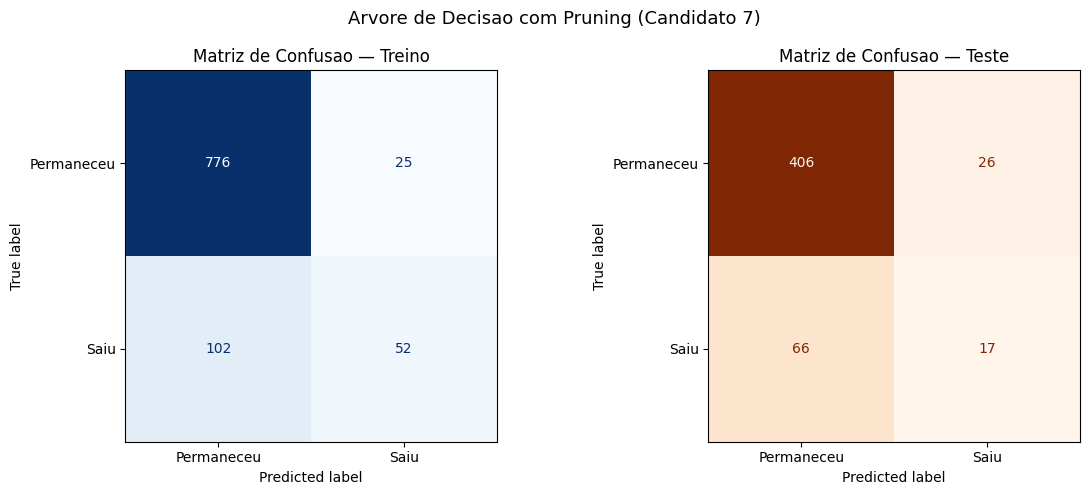

In [79]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao com Pruning (Candidato 7)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

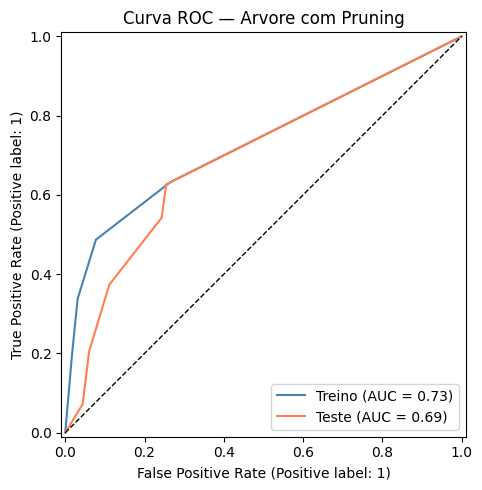

In [80]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore com Pruning")
plt.tight_layout()
plt.savefig("roc_curve_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

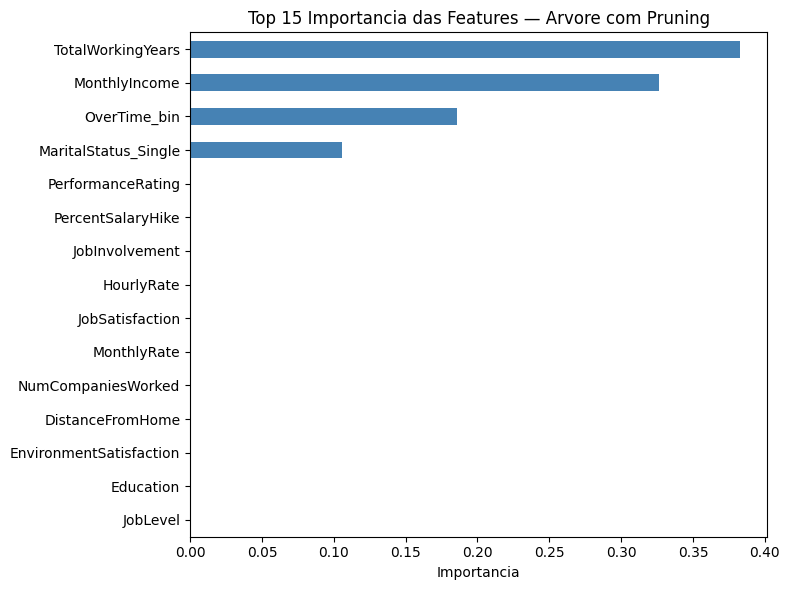

In [81]:
# 8. Visualização 15 atributos mais importantes
feat_imp = pd.Series(clf_pruned.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore com Pruning")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

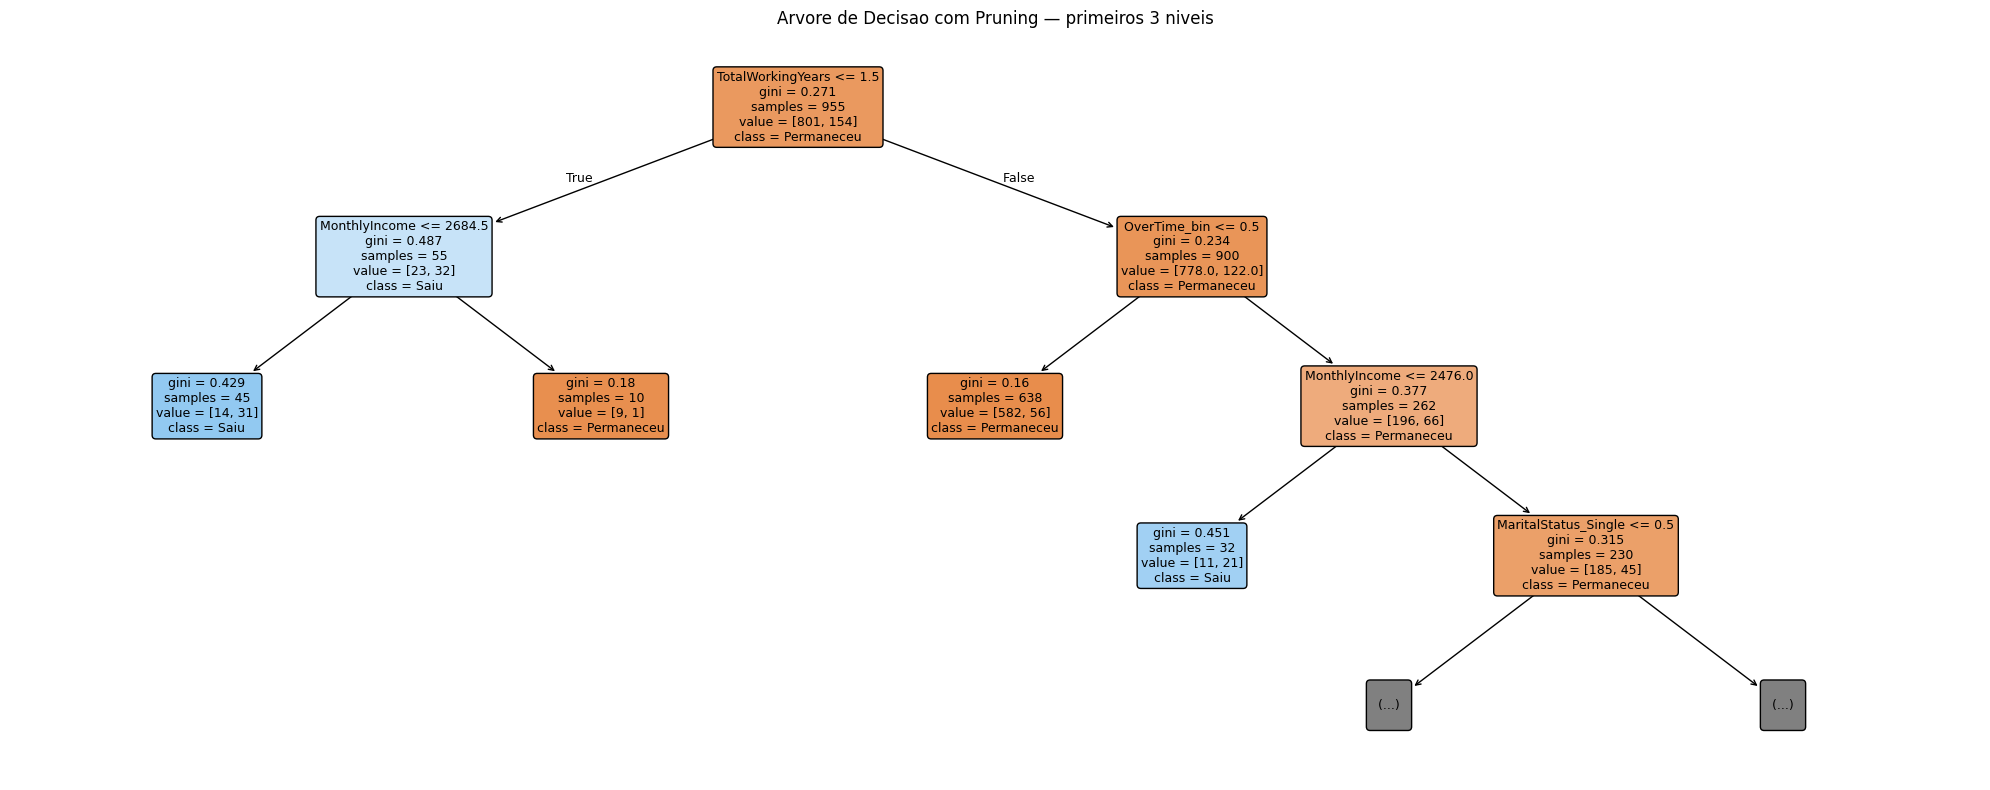

In [82]:
# 9. Visualização - árvore de decisão com pruning
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf_pruned, max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao com Pruning — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
# 10. Análise de matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 406  OK
  FP — Permaneceu, previsto Saiu:       26  Erro
  FN — Saiu, previsto Permaneceu:       66  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 66 saidas reais (Falsos Negativos).


In [84]:
# 11. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 7")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao com Pruning")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  ccp_alpha:         {clf_pruned.ccp_alpha}")
print(f"  Profundidade:      {clf_pruned.get_depth()} niveis")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 7
  Algoritmo:         Arvore de Decisao com Pruning
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  ccp_alpha:         0.005
  Profundidade:      4 niveis
  Metrica principal: F1-Score

  F1 treino: 0.4502
  F1 teste:  0.2698
  Baseline:  0.2483
  Melhoria:  +0.0216


## CANDIDATO 8 - Regressão Logística

In [85]:
# 1. Importações
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [86]:
# 2. Treino do modelo
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(random_state=42))
])
pipeline_lr.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Coeficientes: {pipeline_lr.named_steps['clf'].coef_.shape}")

Modelo treinado.
  Coeficientes: (1, 53)


In [87]:
# 3. Métricas no treino
y_pred_train  = pipeline_lr.predict(X_train)
y_proba_train = pipeline_lr.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6743
  Precision: 0.8224
  Recall:    0.5714
  AUC-ROC:   0.8895

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       801
        Saiu       0.82      0.57      0.67       154

    accuracy                           0.91       955
   macro avg       0.87      0.77      0.81       955
weighted avg       0.91      0.91      0.90       955



In [88]:
# 4. Métricas no teste
y_pred_test  = pipeline_lr.predict(X_test)
y_proba_test = pipeline_lr.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.5538
  Precision: 0.7660
  Recall:    0.4337
  AUC-ROC:   0.8236

              precision    recall  f1-score   support

  Permaneceu       0.90      0.97      0.94       432
        Saiu       0.77      0.43      0.55        83

    accuracy                           0.89       515
   macro avg       0.83      0.70      0.74       515
weighted avg       0.88      0.89      0.87       515



In [89]:
# 5. Tabela comparativa treino vs teste
resultados_lr = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lr)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6743,0.8224,0.5714,0.8895
1,Teste,0.5538,0.7660,0.4337,0.8236



  Diferenca F1 (treino - teste): 0.1205
  --> Sinal de OVERFITTING.


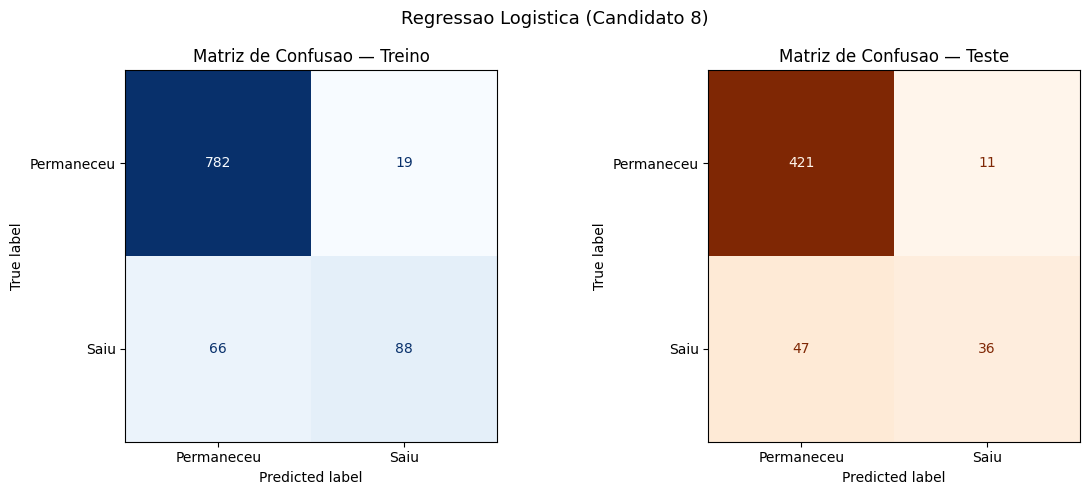

In [90]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Regressao Logistica (Candidato 8)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

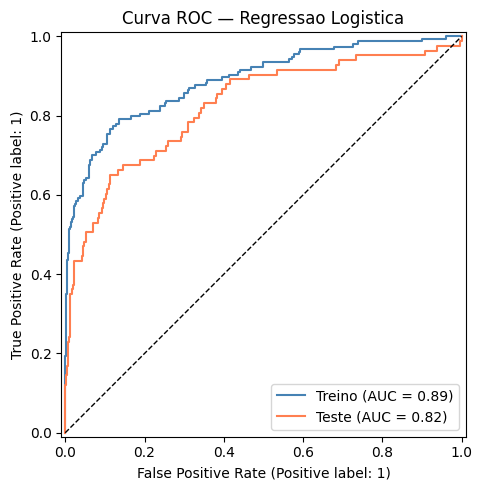

In [91]:
# 7. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Regressao Logistica")
plt.tight_layout()
plt.savefig("roc_curve_lr.png", dpi=150, bbox_inches="tight")
plt.show()

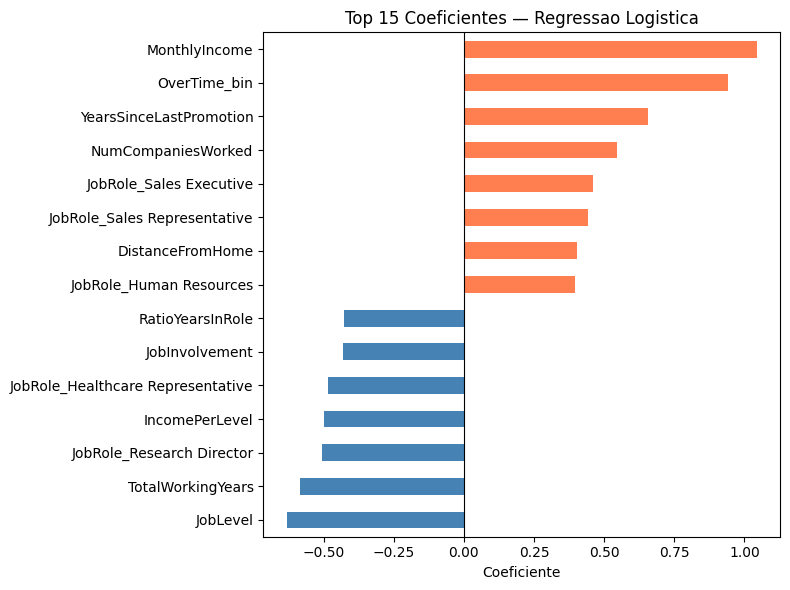

In [92]:
# 8. Visualização 15 coeficientes
coef = pd.Series(
    pipeline_lr.named_steps["clf"].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
coef.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in coef.sort_values()])
ax.set_title("Top 15 Coeficientes — Regressao Logistica")
ax.set_xlabel("Coeficiente")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("coef_lr.png", dpi=150, bbox_inches="tight")
plt.show()

In [93]:
# 9. Análise de matriz confusão (teste)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 421  OK
  FP — Permaneceu, previsto Saiu:       11  Erro
  FN — Saiu, previsto Permaneceu:       47  Erro (critico)
  TP — Saiu, previsto Saiu:             36  OK

  O modelo falhou em detetar 47 saidas reais (Falsos Negativos).


In [94]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 8")
print("=" * 55)
print(f"  Algoritmo:         Regressao Logistica")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 8
  Algoritmo:         Regressao Logistica
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6743
  F1 teste:  0.5538
  Baseline:  0.2483
  Melhoria:  +0.3056


## CANDIDATO 9 - Linear Discriminant Analysis (LDA)

In [95]:
# 1. Importações
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [96]:
# 2. Treino do modelo
clf_lda = LinearDiscriminantAnalysis()
clf_lda.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Componentes discriminantes: {clf_lda.scalings_.shape}")

Modelo treinado.
  Componentes discriminantes: (53, 1)


In [97]:
# 3. Métricas no treino
y_pred_train  = clf_lda.predict(X_train)
y_proba_train = clf_lda.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6512
  Precision: 0.8077
  Recall:    0.5455
  AUC-ROC:   0.8795

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       801
        Saiu       0.81      0.55      0.65       154

    accuracy                           0.91       955
   macro avg       0.86      0.76      0.80       955
weighted avg       0.90      0.91      0.90       955



In [98]:
# 4. Métricas no teste
y_pred_test  = clf_lda.predict(X_test)
y_proba_test = clf_lda.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4651
  Precision: 0.6522
  Recall:    0.3614
  AUC-ROC:   0.8179

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       432
        Saiu       0.65      0.36      0.47        83

    accuracy                           0.87       515
   macro avg       0.77      0.66      0.69       515
weighted avg       0.85      0.87      0.85       515



In [99]:
# 5. Tabela comparativa treino vs teste
resultados_lda = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lda)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6512,0.8077,0.5455,0.8795
1,Teste,0.4651,0.6522,0.3614,0.8179



  Diferenca F1 (treino - teste): 0.1860
  --> Sinal de OVERFITTING.


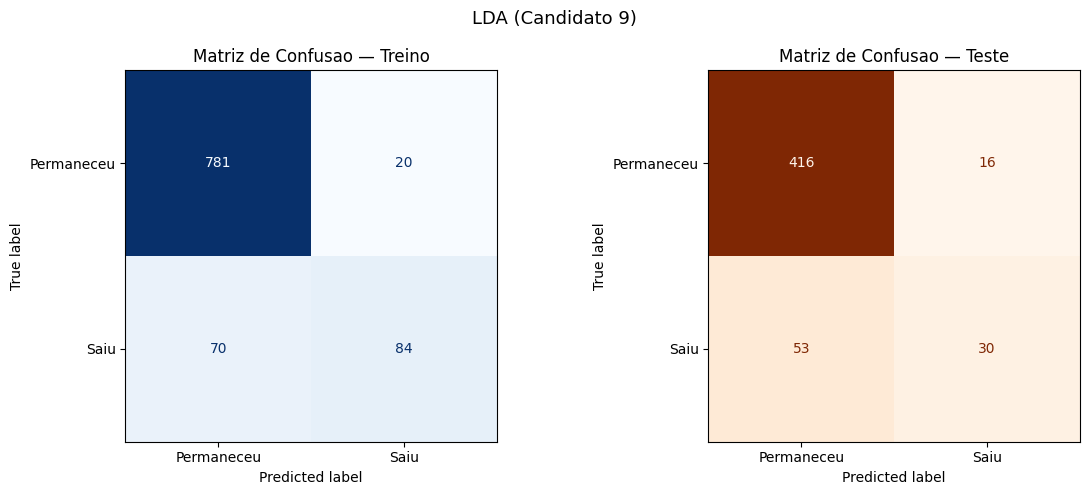

In [100]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LDA (Candidato 9)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lda.png", dpi=150, bbox_inches="tight")
plt.show()

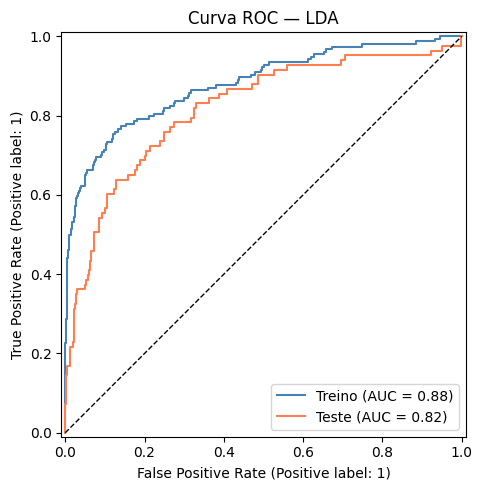

In [101]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LDA")
plt.tight_layout()
plt.savefig("roc_curve_lda.png", dpi=150, bbox_inches="tight")
plt.show()

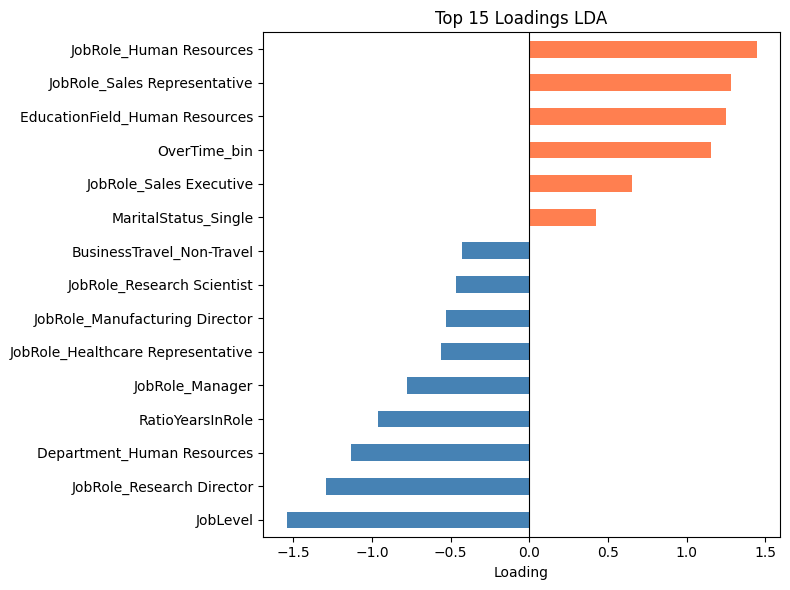

In [102]:
# 8. Visualização top 15 loadings LDA
loadings = pd.Series(clf_lda.scalings_[:, 0], index=X_train.columns).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
loadings.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in loadings.sort_values()])
ax.set_title("Top 15 Loadings LDA")
ax.set_xlabel("Loading")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("loadings_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [103]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 416  OK
  FP — Permaneceu, previsto Saiu:       16  Erro
  FN — Saiu, previsto Permaneceu:       53  Erro (critico)
  TP — Saiu, previsto Saiu:             30  OK

  O modelo falhou em detetar 53 saidas reais (Falsos Negativos).


In [104]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 9")
print("=" * 55)
print(f"  Algoritmo:         Linear Discriminant Analysis")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (LDA faz internamente)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 9
  Algoritmo:         Linear Discriminant Analysis
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (LDA faz internamente)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6512
  F1 teste:  0.4651
  Baseline:  0.2483
  Melhoria:  +0.2168


## CANDIDATO 10 - Naive Bayes (GaussianNB)

In [105]:
# 1. Importações
from sklearn.naive_bayes import GaussianNB
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [106]:
# 2. Treino do modelo
clf_nb = GaussianNB()
clf_nb.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Classes: {clf_nb.classes_}")
print(f"  Probabilidades a priori: {clf_nb.class_prior_.round(3)}")

Modelo treinado.
  Classes: [0 1]
  Probabilidades a priori: [0.839 0.161]


In [107]:
# 3. Métricas no treino
y_pred_train  = clf_nb.predict(X_train)
y_proba_train = clf_nb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4766
  Precision: 0.3627
  Recall:    0.6948
  AUC-ROC:   0.8006

              precision    recall  f1-score   support

  Permaneceu       0.93      0.77      0.84       801
        Saiu       0.36      0.69      0.48       154

    accuracy                           0.75       955
   macro avg       0.65      0.73      0.66       955
weighted avg       0.84      0.75      0.78       955



In [108]:
# 4. Métricas no teste
y_pred_test  = clf_nb.predict(X_test)
y_proba_test = clf_nb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4400
  Precision: 0.3293
  Recall:    0.6627
  AUC-ROC:   0.7447

              precision    recall  f1-score   support

  Permaneceu       0.92      0.74      0.82       432
        Saiu       0.33      0.66      0.44        83

    accuracy                           0.73       515
   macro avg       0.62      0.70      0.63       515
weighted avg       0.82      0.73      0.76       515



In [109]:
# 5. Tabela comparativa treino vs teste
resultados_nb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_nb)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4766,0.3627,0.6948,0.8006
1,Teste,0.4400,0.3293,0.6627,0.7447



  Diferenca F1 (treino - teste): 0.0366
  --> Sem sinais evidentes de overfitting.


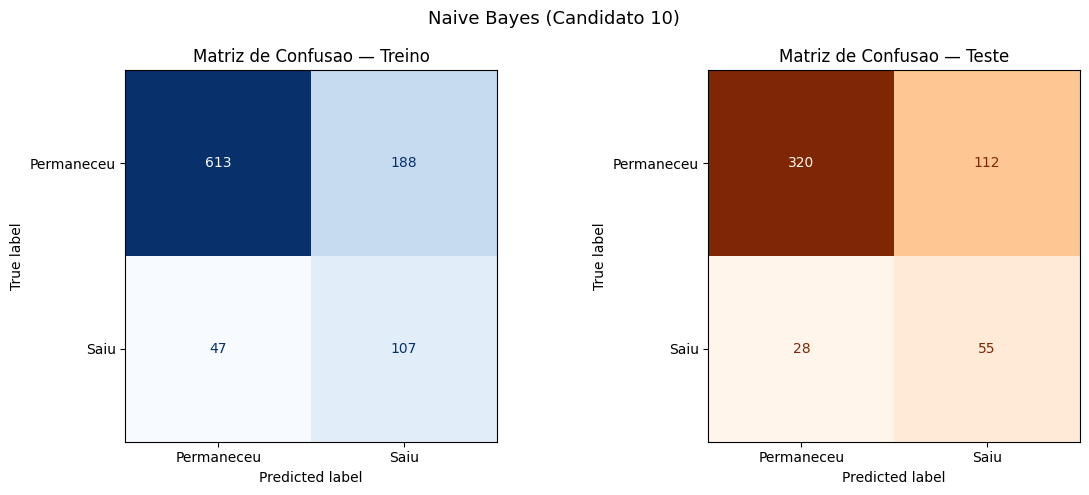

In [110]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Naive Bayes (Candidato 10)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_nb.png", dpi=150, bbox_inches="tight")
plt.show()

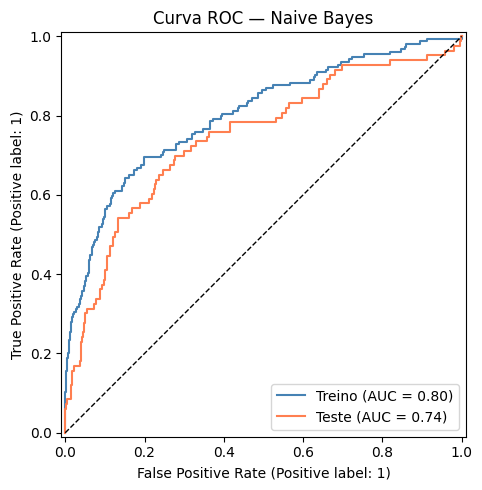

In [111]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Naive Bayes")
plt.tight_layout()
plt.savefig("roc_curve_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [112]:
# 8. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 320  OK
  FP — Permaneceu, previsto Saiu:       112  Erro
  FN — Saiu, previsto Permaneceu:       28  Erro (critico)
  TP — Saiu, previsto Saiu:             55  OK

  O modelo falhou em detetar 28 saidas reais (Falsos Negativos).


In [113]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 10")
print("=" * 55)
print(f"  Algoritmo:         Naive Bayes (GaussianNB)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 10
  Algoritmo:         Naive Bayes (GaussianNB)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4766
  F1 teste:  0.4400
  Baseline:  0.2483
  Melhoria:  +0.1917


## CANDIDATO 11 - K-Nearest Neighbors (KNN)

In [114]:
# 1. Importações
from sklearn.neighbors import KNeighborsClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [115]:
# 2. Treino do modelo
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    KNeighborsClassifier()) 
])
pipeline_knn.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  K (vizinhos): {pipeline_knn.named_steps['clf'].n_neighbors}")

Modelo treinado.
  K (vizinhos): 5


In [116]:
# 3. Métricas no treino
y_pred_train  = pipeline_knn.predict(X_train)
y_proba_train = pipeline_knn.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4712
  Precision: 0.9074
  Recall:    0.3182
  AUC-ROC:   0.9210

              precision    recall  f1-score   support

  Permaneceu       0.88      0.99      0.94       801
        Saiu       0.91      0.32      0.47       154

    accuracy                           0.88       955
   macro avg       0.90      0.66      0.70       955
weighted avg       0.89      0.88      0.86       955



In [117]:
# 4. Métricas no teste
y_pred_test  = pipeline_knn.predict(X_test)
y_proba_test = pipeline_knn.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.1856
  Precision: 0.6429
  Recall:    0.1084
  AUC-ROC:   0.6434

              precision    recall  f1-score   support

  Permaneceu       0.85      0.99      0.92       432
        Saiu       0.64      0.11      0.19        83

    accuracy                           0.85       515
   macro avg       0.75      0.55      0.55       515
weighted avg       0.82      0.85      0.80       515



In [118]:
# 5. Tabela comparativa treino vs teste
resultados_knn = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_knn)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4712,0.9074,0.3182,0.9210
1,Teste,0.1856,0.6429,0.1084,0.6434



  Diferenca F1 (treino - teste): 0.2856
  --> Sinal de OVERFITTING.


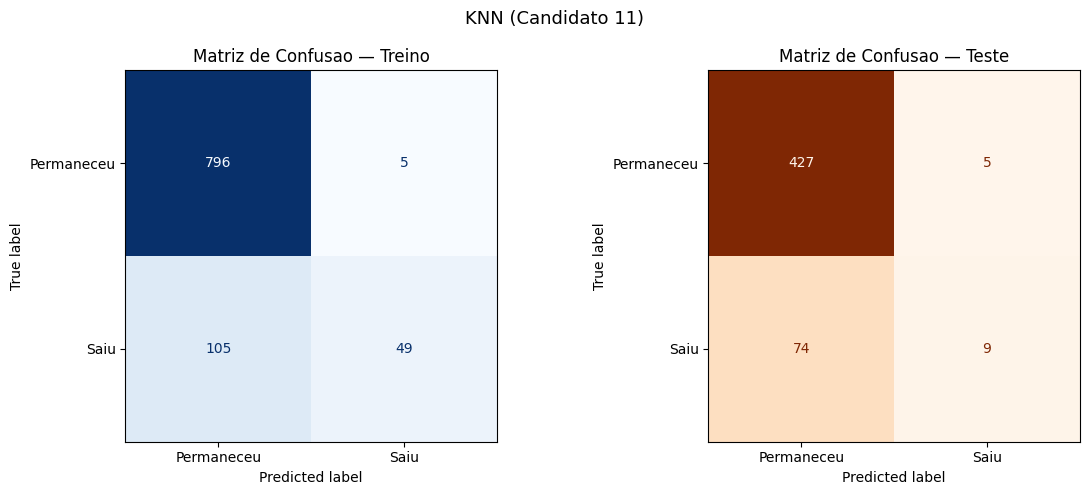

In [119]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("KNN (Candidato 11)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight")
plt.show()

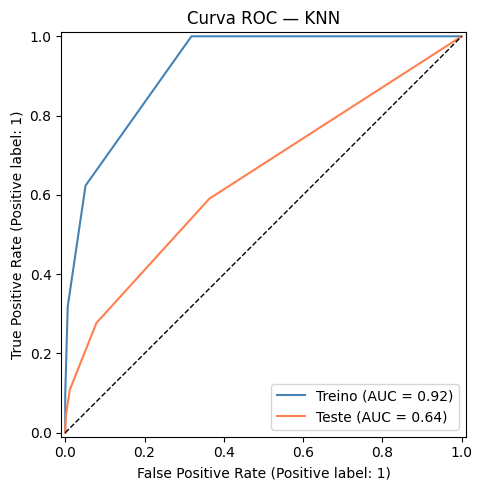

In [120]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — KNN")
plt.tight_layout()
plt.savefig("roc_curve_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [121]:
# 8. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 427  OK
  FP — Permaneceu, previsto Saiu:       5  Erro
  FN — Saiu, previsto Permaneceu:       74  Erro (critico)
  TP — Saiu, previsto Saiu:             9  OK

  O modelo falhou em detetar 74 saidas reais (Falsos Negativos).


In [122]:
# 9. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 11")
print("=" * 55)
print(f"  Algoritmo:         K-Nearest Neighbors")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 11
  Algoritmo:         K-Nearest Neighbors
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4712
  F1 teste:  0.1856
  Baseline:  0.2483
  Melhoria:  -0.0627


## CANDIDATO 12 - Extra Trees

In [123]:
# 1. Importações
from sklearn.ensemble import ExtraTreesClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [124]:
# 2. Treino do modelo
clf_et = ExtraTreesClassifier(random_state=42)
clf_et.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Numero de arvores: {clf_et.n_estimators}")

Modelo treinado.
  Numero de arvores: 100


In [125]:
# 3. Métricas no treino
y_pred_train  = clf_et.predict(X_train)
y_proba_train = clf_et.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [126]:
# 4. Métricas no teste
y_pred_test  = clf_et.predict(X_test)
y_proba_test = clf_et.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2718
  Precision: 0.7000
  Recall:    0.1687
  AUC-ROC:   0.7883

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       432
        Saiu       0.70      0.17      0.27        83

    accuracy                           0.85       515
   macro avg       0.78      0.58      0.60       515
weighted avg       0.83      0.85      0.81       515



In [127]:
# 5. Tabela comparativa treino vs teste
resultados_et = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_et)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0,1.0000,1.0000
1,Teste,0.2718,0.7,0.1687,0.7883



  Diferenca F1 (treino - teste): 0.7282
  --> Sinal de OVERFITTING.


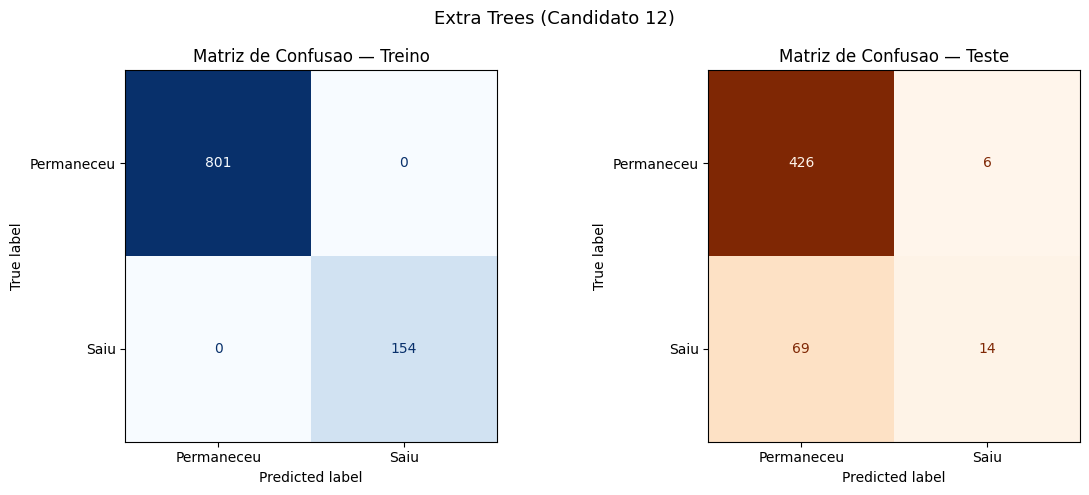

In [128]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Extra Trees (Candidato 12)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_et.png", dpi=150, bbox_inches="tight")
plt.show()

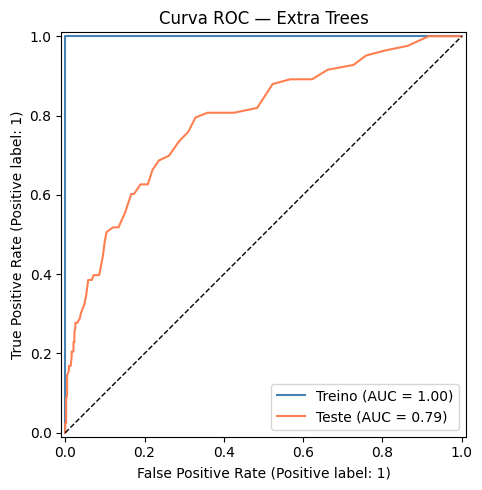

In [129]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Extra Trees")
plt.tight_layout()
plt.savefig("roc_curve_et.png", dpi=150, bbox_inches="tight")
plt.show()

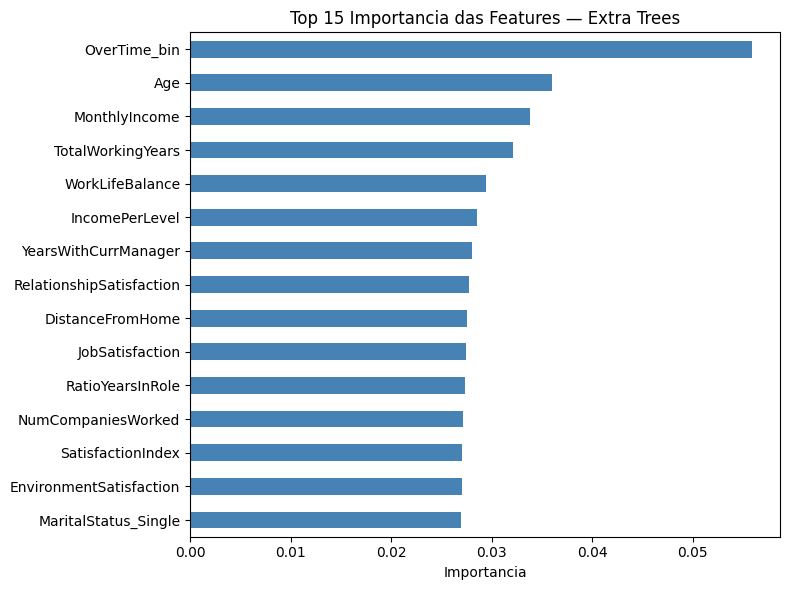

In [130]:
# 8. Visualização 15 atributos mais importantes
feat_imp_et = pd.Series(clf_et.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_et.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Extra Trees")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [131]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 426  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       69  Erro (critico)
  TP — Saiu, previsto Saiu:             14  OK

  O modelo falhou em detetar 69 saidas reais (Falsos Negativos).


In [132]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 12")
print("=" * 55)
print(f"  Algoritmo:         Extra Trees")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 12
  Algoritmo:         Extra Trees
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.2718
  Baseline:  0.2483
  Melhoria:  +0.0236


## CANDIDATO 13 - Rede Neuronal MLP (sklearn)

In [133]:
# 1. Importações
from sklearn.neural_network import MLPClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [134]:
# 2. Treino do modelo
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    MLPClassifier(random_state=42))  
])
pipeline_mlp.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Camadas ocultas: {pipeline_mlp.named_steps['clf'].hidden_layer_sizes}")
print(f"  Iteracoes:       {pipeline_mlp.named_steps['clf'].n_iter_}")

Modelo treinado.
  Camadas ocultas: (100,)
  Iteracoes:       200


In [135]:
# 3. Métricas no treino
y_pred_train  = pipeline_mlp.predict(X_train)
y_proba_train = pipeline_mlp.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [136]:
# 4. Métricas no teste
y_pred_test  = pipeline_mlp.predict(X_test)
y_proba_test = pipeline_mlp.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4789
  Precision: 0.5763
  Recall:    0.4096
  AUC-ROC:   0.7869

              precision    recall  f1-score   support

  Permaneceu       0.89      0.94      0.92       432
        Saiu       0.58      0.41      0.48        83

    accuracy                           0.86       515
   macro avg       0.73      0.68      0.70       515
weighted avg       0.84      0.86      0.85       515



In [137]:
# 5. Tabela comparativa treino vs teste
resultados_mlp = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_mlp)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.4789,0.5763,0.4096,0.7869



  Diferenca F1 (treino - teste): 0.5211
  --> Sinal de OVERFITTING.


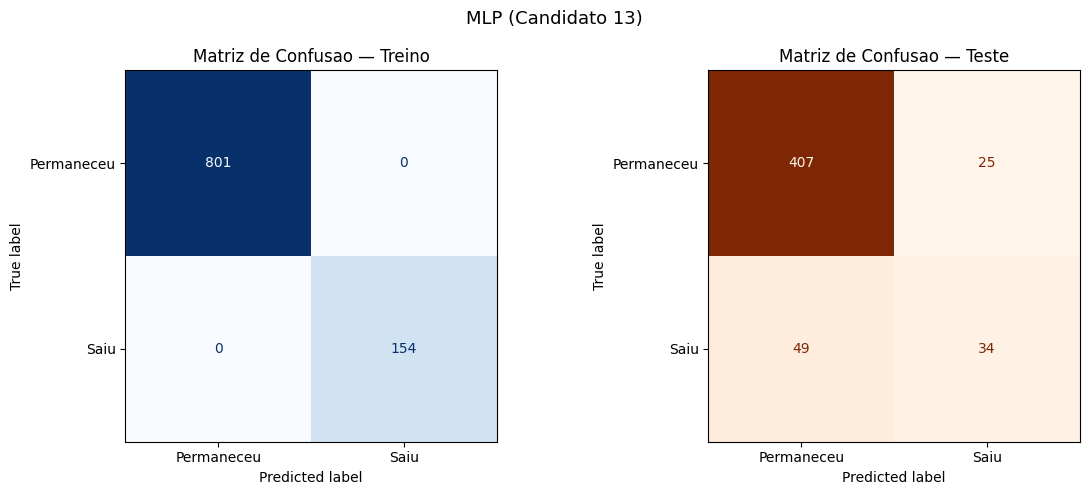

In [138]:
# 6. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("MLP (Candidato 13)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

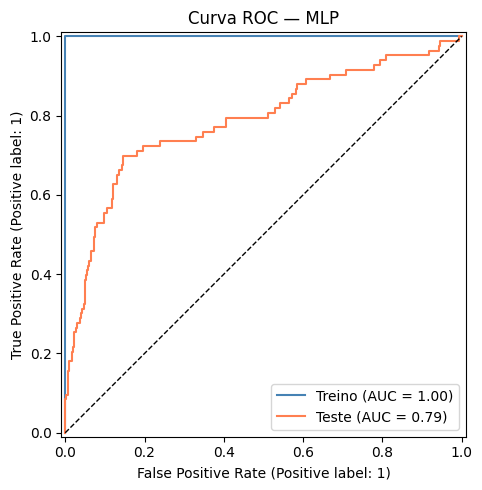

In [139]:
# 7. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — MLP")
plt.tight_layout()
plt.savefig("roc_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

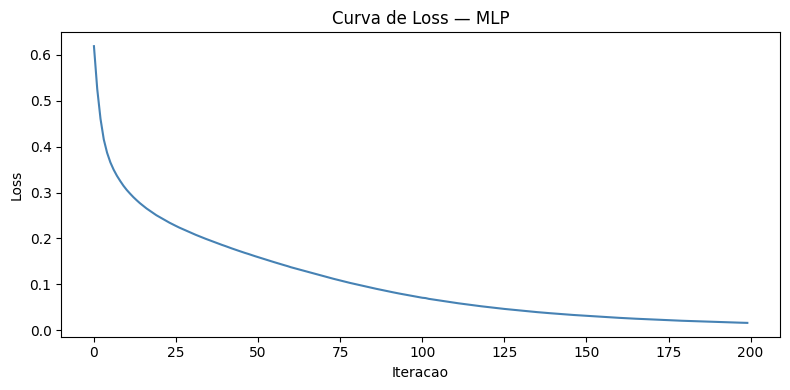

In [140]:
# 8. Visualização — curva de aprendizagem
mlp_model = pipeline_mlp.named_steps["clf"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_model.loss_curve_, color="steelblue")
ax.set_title("Curva de Loss — MLP")
ax.set_xlabel("Iteracao")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.savefig("loss_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

In [141]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 407  OK
  FP — Permaneceu, previsto Saiu:       25  Erro
  FN — Saiu, previsto Permaneceu:       49  Erro (critico)
  TP — Saiu, previsto Saiu:             34  OK

  O modelo falhou em detetar 49 saidas reais (Falsos Negativos).


In [142]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 13")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal MLP (sklearn)")
print(f"  Arquitetura:       {pipeline_mlp.named_steps['clf'].hidden_layer_sizes} (default)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 13
  Algoritmo:         Rede Neuronal MLP (sklearn)
  Arquitetura:       (100,) (default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.4789
  Baseline:  0.2483
  Melhoria:  +0.2306


## CANDIDATO 14 - Rede Neuronal TabNet (pytorch-tabnet)

In [143]:
# 1. Instalação e importações
import subprocess
subprocess.run(["pip", "install", "pytorch-tabnet", "-q"], check=True)

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [144]:
# 2. Preparação dos dados
scaler_tab = SS()
X_train_tab = scaler_tab.fit_transform(X_train).astype(np.float32)
X_test_tab  = scaler_tab.transform(X_test).astype(np.float32)
y_train_tab = y_train.values.reshape(-1)
y_test_tab  = y_test.values.reshape(-1)
print(f"X_train_tab shape: {X_train_tab.shape}")
print(f"X_test_tab shape:  {X_test_tab.shape}")

X_train_tab shape: (955, 53)
X_test_tab shape:  (515, 53)


In [145]:
# 3. Treino do modelo
clf_tabnet = TabNetClassifier(verbose=0, seed=42)
clf_tabnet.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_metric=["auc"],
    batch_size=256,
    virtual_batch_size=128,
    max_epochs=100,
    patience=15,
)
print("Modelo treinado.")
print(f"  Melhor epoca: {clf_tabnet.best_epoch}")


Early stopping occurred at epoch 24 with best_epoch = 9 and best_val_0_auc = 0.67657
Modelo treinado.
  Melhor epoca: 9


In [146]:
# 4. Métricas no treino
y_pred_train  = clf_tabnet.predict(X_train_tab)
y_proba_train = clf_tabnet.predict_proba(X_train_tab)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_tab, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_tab, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_tab, y_proba_train):.4f}")
print()
print(classification_report(y_train_tab, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.0854
  Precision: 0.7000
  Recall:    0.0455
  AUC-ROC:   0.7365

              precision    recall  f1-score   support

  Permaneceu       0.84      1.00      0.91       801
        Saiu       0.70      0.05      0.09       154

    accuracy                           0.84       955
   macro avg       0.77      0.52      0.50       955
weighted avg       0.82      0.84      0.78       955



In [147]:
# 5. Métricas no teste
y_pred_test  = clf_tabnet.predict(X_test_tab)
y_proba_test = clf_tabnet.predict_proba(X_test_tab)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_tab, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_tab, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_tab, y_proba_test):.4f}")
print()
print(classification_report(y_test_tab, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.0235
  Precision: 0.5000
  Recall:    0.0120
  AUC-ROC:   0.6766

              precision    recall  f1-score   support

  Permaneceu       0.84      1.00      0.91       432
        Saiu       0.50      0.01      0.02        83

    accuracy                           0.84       515
   macro avg       0.67      0.50      0.47       515
weighted avg       0.79      0.84      0.77       515



In [148]:
# 6. Tabela comparativa treino vs teste
resultados_tabnet = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_tab, y_pred_train),        f1_score(y_test_tab, y_pred_test)],
    "Precision": [precision_score(y_train_tab, y_pred_train), precision_score(y_test_tab, y_pred_test)],
    "Recall":    [recall_score(y_train_tab, y_pred_train),    recall_score(y_test_tab, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_tab, y_proba_train),  roc_auc_score(y_test_tab, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_tabnet)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train_tab, y_pred_train) - f1_score(y_test_tab, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.0854,0.7,0.0455,0.7365
1,Teste,0.0235,0.5,0.0120,0.6766



  Diferenca F1 (treino - teste): 0.0618
  --> Sem sinais evidentes de overfitting.


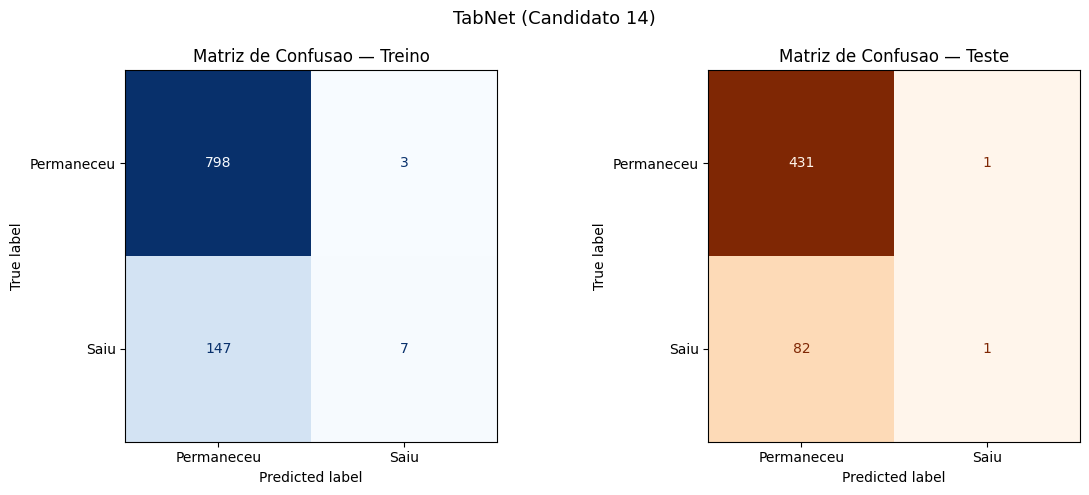

In [149]:
# 7. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_tab, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_tab, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("TabNet (Candidato 14)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

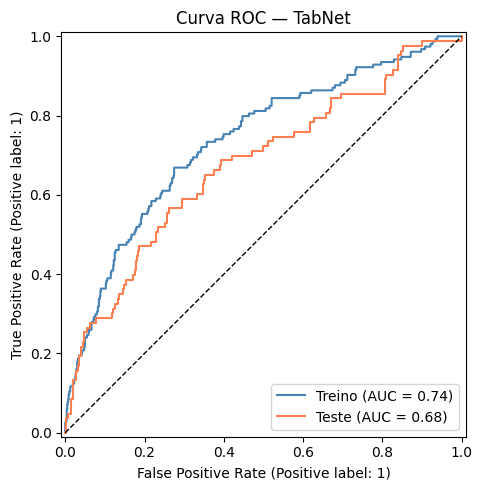

In [150]:
# 8. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_tab, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_tab,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — TabNet")
plt.tight_layout()
plt.savefig("roc_curve_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

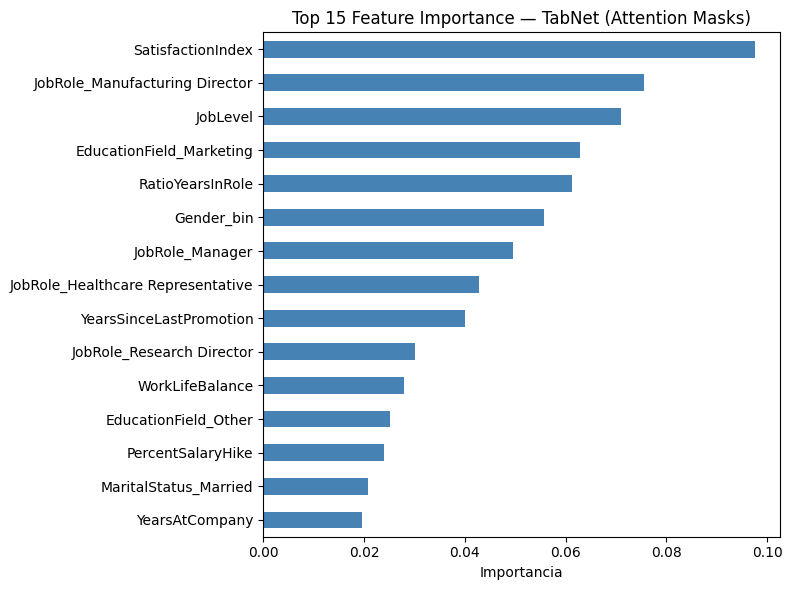

In [151]:
# 9. Visualização 15 atributos mais importantes
feat_imp_tabnet = pd.Series(
    clf_tabnet.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_tabnet.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Feature Importance — TabNet (Attention Masks)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

In [152]:
# 10. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test_tab, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 431  OK
  FP — Permaneceu, previsto Saiu:       1  Erro
  FN — Saiu, previsto Permaneceu:       82  Erro (critico)
  TP — Saiu, previsto Saiu:             1  OK

  O modelo falhou em detetar 82 saidas reais (Falsos Negativos).


In [153]:
# 11. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 14")
print("=" * 55)
print(f"  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test_tab, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 14
  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.0854
  F1 teste:  0.0235
  Baseline:  0.2483
  Melhoria:  -0.2247


## CANDIDATO 15 - Rede Neuronal Keras

In [154]:
# 1. Instalação e importações
import subprocess
subprocess.run(["pip", "install", "tensorflow", "-q"], check=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print(f"TensorFlow versão: {tf.__version__}")
print("Bibliotecas importadas com sucesso.")

2026-05-15 22:09:13.438329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778882953.628069      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778882953.679223      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778882954.197063      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778882954.197096      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778882954.197098      16 computation_placer.cc:177] computation placer alr

TensorFlow versão: 2.19.0
Bibliotecas importadas com sucesso.


In [155]:
# 2. Preparação dos dados
scaler_keras = SS()
X_train_keras = scaler_keras.fit_transform(X_train).astype(np.float32)
X_test_keras  = scaler_keras.transform(X_test).astype(np.float32)
y_train_keras = y_train.values.astype(np.float32)
y_test_keras  = y_test.values.astype(np.float32)
print(f"X_train_keras shape: {X_train_keras.shape}")
print(f"X_test_keras shape:  {X_test_keras.shape}")

X_train_keras shape: (955, 53)
X_test_keras shape:  (515, 53)


In [156]:
# 3. Treino do modelo
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_keras.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])

model_keras.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

model_keras.summary()

history_keras = model_keras.fit(
    X_train_keras, y_train_keras,
    validation_data=(X_test_keras, y_test_keras),
    epochs=100,
    batch_size=32,
    verbose=0,
)
print("Modelo treinado.")
print(f"  Épocas treinadas: {len(history_keras.history['loss'])}")

2026-05-15 22:09:35.725771: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo treinado.
  Épocas treinadas: 100


In [157]:
# 4. Métricas no treino
y_proba_train = model_keras.predict(X_train_keras, verbose=0).flatten()
y_pred_train  = (y_proba_train >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_keras, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_keras, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_keras, y_proba_train):.4f}")
print()
print(classification_report(y_train_keras, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      1.00      1.00       154

    accuracy                           1.00       955
   macro avg       1.00      1.00      1.00       955
weighted avg       1.00      1.00      1.00       955



In [158]:
# 5. Métricas no teste
y_proba_test = model_keras.predict(X_test_keras, verbose=0).flatten()
y_pred_test  = (y_proba_test >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_keras, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_keras, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_keras, y_proba_test):.4f}")
print()
print(classification_report(y_test_keras, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4828
  Precision: 0.5645
  Recall:    0.4217
  AUC-ROC:   0.7814

              precision    recall  f1-score   support

  Permaneceu       0.89      0.94      0.92       432
        Saiu       0.56      0.42      0.48        83

    accuracy                           0.85       515
   macro avg       0.73      0.68      0.70       515
weighted avg       0.84      0.85      0.85       515



In [159]:
# 6. Tabela comparativa treino vs teste
resultados_keras = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_keras, y_pred_train),        f1_score(y_test_keras, y_pred_test)],
    "Precision": [precision_score(y_train_keras, y_pred_train), precision_score(y_test_keras, y_pred_test)],
    "Recall":    [recall_score(y_train_keras, y_pred_train),    recall_score(y_test_keras, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_keras, y_proba_train),  roc_auc_score(y_test_keras, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_keras)
diff = f1_score(y_train_keras, y_pred_train) - f1_score(y_test_keras, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.4828,0.5645,0.4217,0.7814



  Diferenca F1 (treino - teste): 0.5172
  --> Sinal de OVERFITTING.


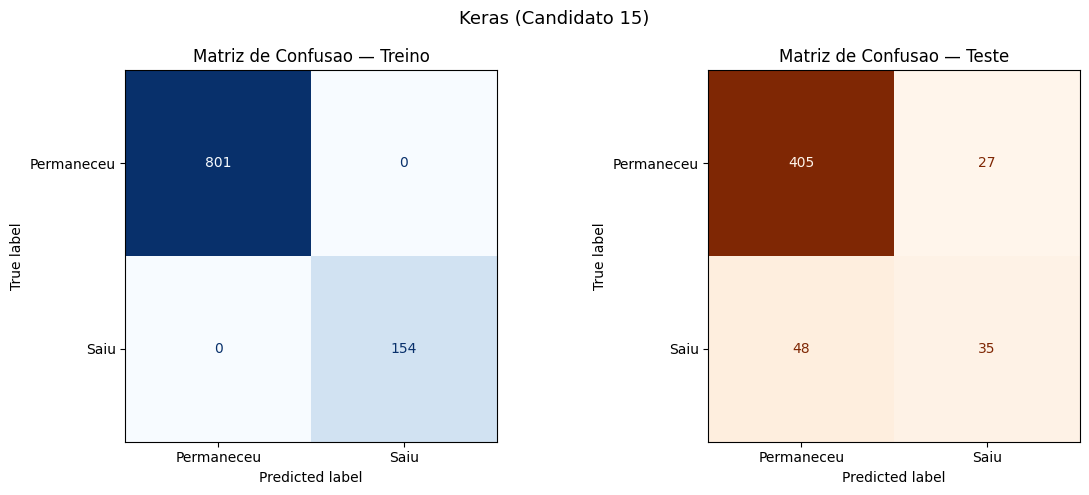

In [160]:
# 7. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_keras, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_keras, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras (Candidato 15)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_keras.png", dpi=150, bbox_inches="tight")
plt.show()

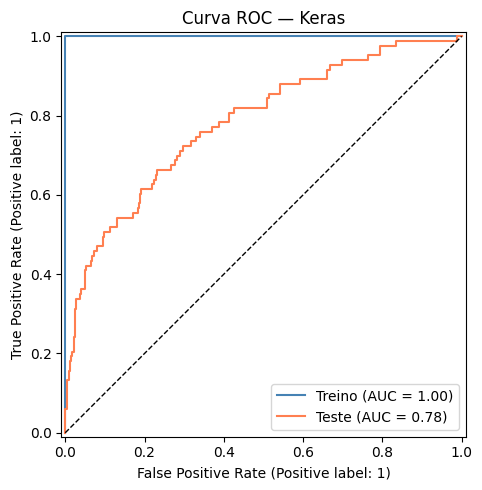

In [161]:
# 8. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_keras, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_keras,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras")
plt.tight_layout()
plt.savefig("roc_curve_keras.png", dpi=150, bbox_inches="tight")
plt.show()

Chaves disponíveis: ['AUC', 'loss', 'val_AUC', 'val_loss']
  auc_key:     AUC
  val_auc_key: val_AUC


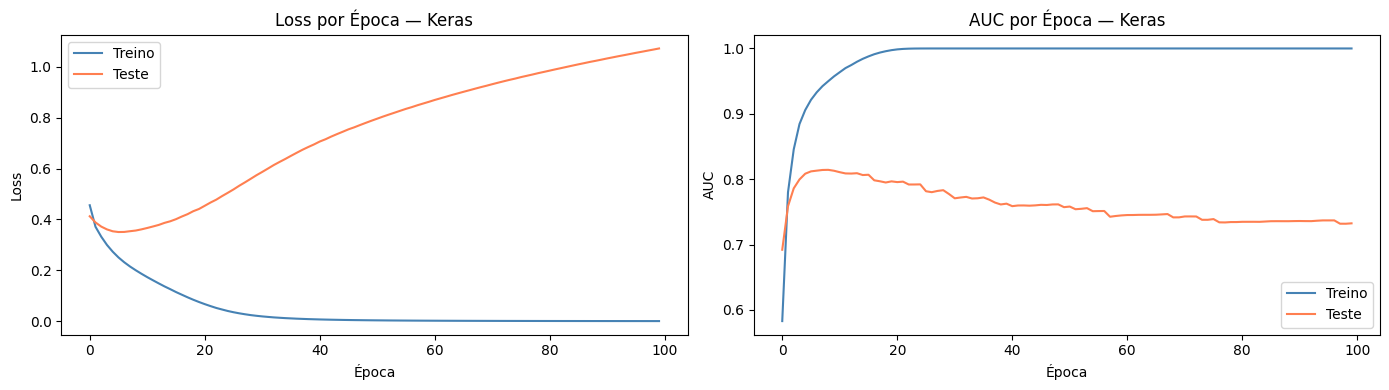

In [162]:
# 9. Visualização - curvas de loss e AUC durante treino
all_keys    = list(history_keras.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)

print(f"Chaves disponíveis: {all_keys}")
print(f"  auc_key:     {auc_key}")
print(f"  val_auc_key: {val_auc_key}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_keras.history["loss"],     label="Treino", color="steelblue")
axes[0].plot(history_keras.history["val_loss"], label="Teste",  color="coral")
axes[0].set_title("Loss por Época — Keras")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

if auc_key and val_auc_key:
    axes[1].plot(history_keras.history[auc_key],     label="Treino", color="steelblue")
    axes[1].plot(history_keras.history[val_auc_key], label="Teste",  color="coral")
    axes[1].set_title(f"AUC por Época — Keras")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Metrica AUC nao encontrada no history",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("AUC por Época — Keras")

plt.tight_layout()
plt.savefig("history_keras.png", dpi=150, bbox_inches="tight")
plt.show()

In [163]:
# 10. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test_keras, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 405  OK
  FP — Permaneceu, previsto Saiu:       27  Erro
  FN — Saiu, previsto Permaneceu:       48  Erro (critico)
  TP — Saiu, previsto Saiu:             35  OK

  O modelo falhou em detetar 48 saidas reais (Falsos Negativos).


In [164]:
# 11. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 15")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal Keras (TensorFlow)")
print(f"  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)")
print(f"  Features:          {X_train_keras.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test_keras, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 15
  Algoritmo:         Rede Neuronal Keras (TensorFlow)
  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.4828
  Baseline:  0.2483
  Melhoria:  +0.2345


## CANDIDATO 16 - Keras com Dropout + BatchNormalization

In [165]:
# 1. Importações
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [166]:
# 2. Preparação dos dados
scaler_k16 = SS()
X_train_k16 = scaler_k16.fit_transform(X_train).astype(np.float32)
X_test_k16  = scaler_k16.transform(X_test).astype(np.float32)
y_train_k16 = y_train.values.astype(np.float32)
y_test_k16  = y_test.values.astype(np.float32)
print(f"X_train_k16 shape: {X_train_k16.shape}")
print(f"X_test_k16 shape:  {X_test_k16.shape}")

X_train_k16 shape: (955, 53)
X_test_k16 shape:  (515, 53)


In [167]:
# 3. Treino do modelo
tf.random.set_seed(42)
model_k16 = keras.Sequential([
    layers.Input(shape=(X_train_k16.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_k16.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
model_k16.summary()
history_k16 = model_k16.fit(
    X_train_k16, y_train_k16,
    validation_data=(X_test_k16, y_test_k16),
    epochs=100, batch_size=32, verbose=0,
)
print("Modelo treinado.")
print(f"  Epocas treinadas: {len(history_k16.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,049 (70.50 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 384 (1.50 KB)

Modelo treinado.
  Epocas treinadas: 100


In [168]:
# 4. Métricas no treino
y_proba_train_k16 = model_k16.predict(X_train_k16, verbose=0).flatten()
y_pred_train_k16  = (y_proba_train_k16 >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Precision: {precision_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Recall:    {recall_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_k16, y_proba_train_k16):.4f}")
print()
print(classification_report(y_train_k16, y_pred_train_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9902
  Precision: 1.0000
  Recall:    0.9805
  AUC-ROC:   0.9999

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       801
        Saiu       1.00      0.98      0.99       154

    accuracy                           1.00       955
   macro avg       1.00      0.99      0.99       955
weighted avg       1.00      1.00      1.00       955



In [169]:
# 5. Métricas no teste
y_proba_test_k16 = model_k16.predict(X_test_k16, verbose=0).flatten()
y_pred_test_k16  = (y_proba_test_k16 >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Precision: {precision_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Recall:    {recall_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_k16, y_proba_test_k16):.4f}")
print()
print(classification_report(y_test_k16, y_pred_test_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4853
  Precision: 0.6226
  Recall:    0.3976
  AUC-ROC:   0.7578

              precision    recall  f1-score   support

  Permaneceu       0.89      0.95      0.92       432
        Saiu       0.62      0.40      0.49        83

    accuracy                           0.86       515
   macro avg       0.76      0.68      0.70       515
weighted avg       0.85      0.86      0.85       515



In [170]:
# 6. Tabela comparativa treino vs teste
resultados_k16 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_k16, y_pred_train_k16),        f1_score(y_test_k16, y_pred_test_k16)],
    "Precision": [precision_score(y_train_k16, y_pred_train_k16), precision_score(y_test_k16, y_pred_test_k16)],
    "Recall":    [recall_score(y_train_k16, y_pred_train_k16),    recall_score(y_test_k16, y_pred_test_k16)],
    "AUC-ROC":   [roc_auc_score(y_train_k16, y_proba_train_k16),  roc_auc_score(y_test_k16, y_proba_test_k16)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_k16)
diff = f1_score(y_train_k16, y_pred_train_k16) - f1_score(y_test_k16, y_pred_test_k16)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9902,1.0000,0.9805,0.9999
1,Teste,0.4853,0.6226,0.3976,0.7578



  Diferenca F1 (treino - teste): 0.5049
  --> Sinal de OVERFITTING.


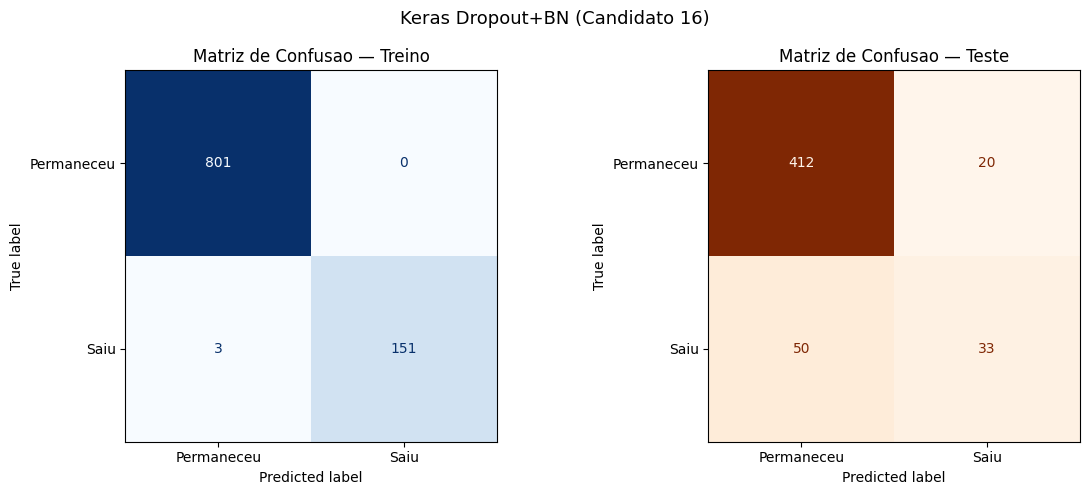

In [171]:
# 7. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_k16, y_pred_train_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_k16, y_pred_test_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras Dropout+BN (Candidato 16)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_k16.png", dpi=150, bbox_inches="tight")
plt.show()

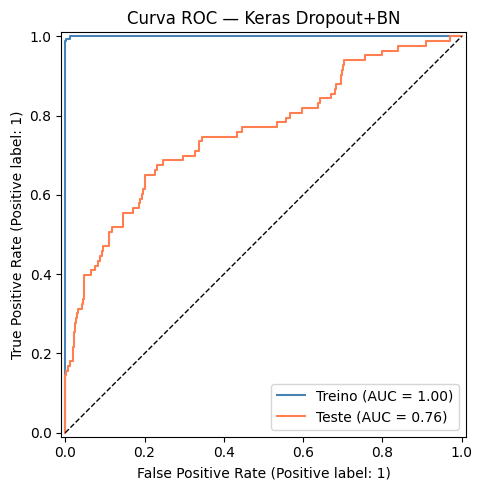

In [172]:
# 8. Visualização - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_k16, y_proba_train_k16, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_k16,  y_proba_test_k16,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras Dropout+BN")
plt.tight_layout()
plt.savefig("roc_curve_k16.png", dpi=150, bbox_inches="tight")
plt.show()

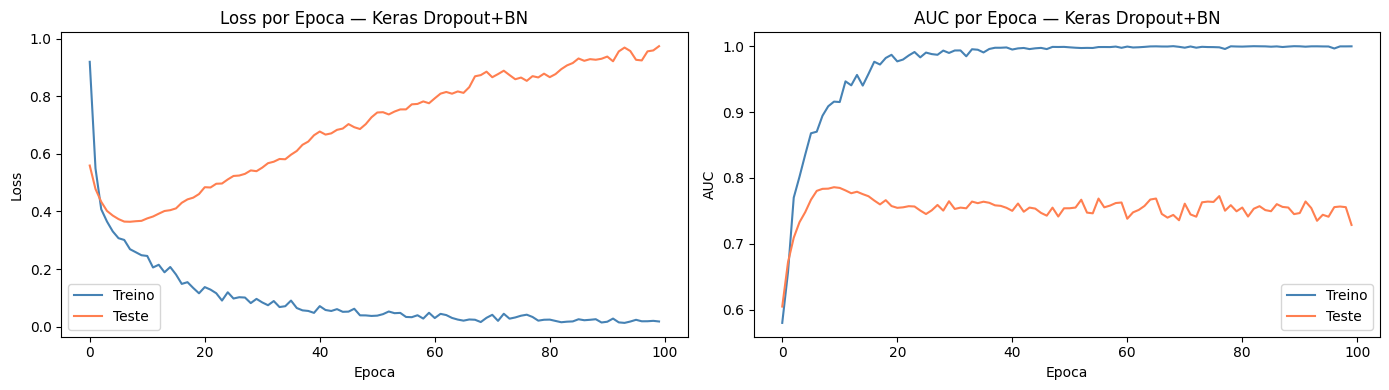

In [173]:
# 9. Visualização - curvas de loss e AUC durante treino
all_keys    = list(history_k16.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_k16.history["loss"], label="Treino", color="steelblue")
axes[0].plot(history_k16.history["val_loss"], label="Teste", color="coral")
axes[0].set_title("Loss por Epoca — Keras Dropout+BN")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()
if auc_key and val_auc_key:
    axes[1].plot(history_k16.history[auc_key], label="Treino", color="steelblue")
    axes[1].plot(history_k16.history[val_auc_key], label="Teste", color="coral")
    axes[1].set_title("AUC por Epoca — Keras Dropout+BN")
    axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("AUC"); axes[1].legend()
plt.tight_layout()
plt.savefig("history_k16.png", dpi=150, bbox_inches="tight")
plt.show()

In [174]:
# 10. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test_k16, y_pred_test_k16).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 412  OK
  FP — Permaneceu, previsto Saiu:       20  Erro
  FN — Saiu, previsto Permaneceu:       50  Erro (critico)
  TP — Saiu, previsto Saiu:             33  OK

  O modelo falhou em detetar 50 saidas reais (Falsos Negativos).


In [175]:
# 11. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 16")
print("=" * 55)
print(f"  Algoritmo:         Keras com Dropout + BatchNormalization")
print(f"  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1")
print(f"  Features:          {X_train_k16.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  F1 teste:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test_k16, y_pred_test_k16) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 16
  Algoritmo:         Keras com Dropout + BatchNormalization
  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9902
  F1 teste:  0.4853
  Baseline:  0.2483
  Melhoria:  +0.2370


## CANDIDATO 17 - GANDALF (pytorch-tabular)

In [176]:
# 1. Instalação e importações
import subprocess
subprocess.run(["pip", "install", "pytorch-tabular", "-q"], check=True)

from pytorch_tabular import TabularModel
from pytorch_tabular.models import GANDALFConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.3 MB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [177]:
# 2. Preparação dos dados
feature_cols = X_train.columns.tolist()
TARGET_COL   = "Attrition_bin"

df_train_g17 = X_train.copy(); df_train_g17[TARGET_COL] = y_train.values
df_test_g17  = X_test.copy();  df_test_g17[TARGET_COL]  = y_test.values
print(f"df_train_g17 shape: {df_train_g17.shape}")
print(f"df_test_g17 shape:  {df_test_g17.shape}")

df_train_g17 shape: (955, 54)
df_test_g17 shape:  (515, 54)


In [178]:
# 3. Treino do modelo
data_config_g17 = DataConfig(
    target=[TARGET_COL],
    continuous_cols=feature_cols,
    categorical_cols=[],
)
trainer_config_g17 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g17 = GANDALFConfig(task="classification")

tabular_gandalf = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g17,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g17,
    verbose=False,
)
tabular_gandalf.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-15 22:10:37,011 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [179]:
# 4. Métricas no treino
pred_train_g17    = tabular_gandalf.predict(df_train_g17)
y_pred_train_g17  = pred_train_g17["Attrition_bin_prediction"].values
y_proba_train_g17 = pred_train_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g17):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g17):.4f}")
print()
print(classification_report(y_train, y_pred_train_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.7732
  Precision: 0.9043
  Recall:    0.6753
  AUC-ROC:   0.9507

              precision    recall  f1-score   support

  Permaneceu       0.94      0.99      0.96       801
        Saiu       0.90      0.68      0.77       154

    accuracy                           0.94       955
   macro avg       0.92      0.83      0.87       955
weighted avg       0.93      0.94      0.93       955



In [180]:
# 5. Métricas no teste
pred_test_g17    = tabular_gandalf.predict(df_test_g17)
y_pred_test_g17  = pred_test_g17["Attrition_bin_prediction"].values
y_proba_test_g17 = pred_test_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g17):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g17):.4f}")
print()
print(classification_report(y_test, y_pred_test_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.5333
  Precision: 0.6923
  Recall:    0.4337
  AUC-ROC:   0.8192

              precision    recall  f1-score   support

  Permaneceu       0.90      0.96      0.93       432
        Saiu       0.69      0.43      0.53        83

    accuracy                           0.88       515
   macro avg       0.80      0.70      0.73       515
weighted avg       0.87      0.88      0.87       515



In [181]:
# 6. Tabela comparativa treino vs teste
resultados_g17 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g17),        f1_score(y_test, y_pred_test_g17)],
    "Precision": [precision_score(y_train, y_pred_train_g17), precision_score(y_test, y_pred_test_g17)],
    "Recall":    [recall_score(y_train, y_pred_train_g17),    recall_score(y_test, y_pred_test_g17)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g17),  roc_auc_score(y_test, y_proba_test_g17)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g17)
diff = f1_score(y_train, y_pred_train_g17) - f1_score(y_test, y_pred_test_g17)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.7732,0.9043,0.6753,0.9507
1,Teste,0.5333,0.6923,0.4337,0.8192



  Diferenca F1 (treino - teste): 0.2399
  --> Sinal de OVERFITTING.


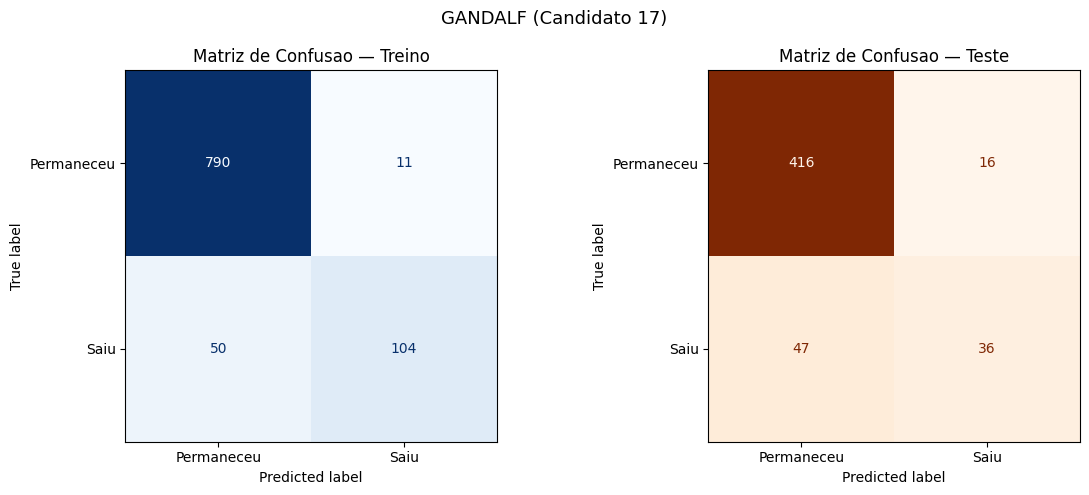

In [182]:
# 7. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("GANDALF (Candidato 17)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

In [183]:
# 8. Visualizão - curva ROC (treino e teste)
RocCurveDisplay.from_predictions(y_train, y_proba_train_g17, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g17,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — GANDALF")
plt.tight_layout()
plt.savefig("roc_curve_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [184]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g17).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 416  OK
  FP — Permaneceu, previsto Saiu:       16  Erro
  FN — Saiu, previsto Permaneceu:       47  Erro (critico)
  TP — Saiu, previsto Saiu:             36  OK

  O modelo falhou em detetar 47 saidas reais (Falsos Negativos).


In [185]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 17")
print("=" * 55)
print(f"  Algoritmo:         GANDALF (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g17) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 17
  Algoritmo:         GANDALF (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.7732
  F1 teste:  0.5333
  Baseline:  0.2483
  Melhoria:  +0.2851


## CANDIDATO 18 - FT-Transformer (pytorch-tabular)

In [186]:
# 1. Importações
from pytorch_tabular.models import FTTransformerConfig
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [187]:
# 2. Preparação de dados
print(f"df_train shape: {df_train_g17.shape}")
print(f"df_test shape:  {df_test_g17.shape}")

df_train shape: (955, 54)
df_test shape:  (515, 54)


In [188]:
# 3. Treino do modelo
trainer_config_g18 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g18 = FTTransformerConfig(task="classification")

tabular_ftt = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g18,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g18,
    verbose=False,
)
tabular_ftt.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-15 22:13:42,919 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [189]:
# 4. Métricas no treino
pred_train_g18    = tabular_ftt.predict(df_train_g17)
y_pred_train_g18  = pred_train_g18["Attrition_bin_prediction"].values
y_proba_train_g18 = pred_train_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g18):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g18):.4f}")
print()
print(classification_report(y_train, y_pred_train_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.7143
  Precision: 0.9184
  Recall:    0.5844
  AUC-ROC:   0.9014

              precision    recall  f1-score   support

  Permaneceu       0.93      0.99      0.96       801
        Saiu       0.92      0.58      0.71       154

    accuracy                           0.92       955
   macro avg       0.92      0.79      0.84       955
weighted avg       0.92      0.92      0.92       955



In [190]:
# 5. Métricas no teste
pred_test_g18    = tabular_ftt.predict(df_test_g17)
y_pred_test_g18  = pred_test_g18["Attrition_bin_prediction"].values
y_proba_test_g18 = pred_test_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g18):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g18):.4f}")
print()
print(classification_report(y_test, y_pred_test_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.5238
  Precision: 0.7674
  Recall:    0.3976
  AUC-ROC:   0.8449

              precision    recall  f1-score   support

  Permaneceu       0.89      0.98      0.93       432
        Saiu       0.77      0.40      0.52        83

    accuracy                           0.88       515
   macro avg       0.83      0.69      0.73       515
weighted avg       0.87      0.88      0.87       515



In [191]:
# 6. Tabela comparativa treino vs teste
resultados_g18 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g18),        f1_score(y_test, y_pred_test_g18)],
    "Precision": [precision_score(y_train, y_pred_train_g18), precision_score(y_test, y_pred_test_g18)],
    "Recall":    [recall_score(y_train, y_pred_train_g18),    recall_score(y_test, y_pred_test_g18)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g18),  roc_auc_score(y_test, y_proba_test_g18)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g18)
diff = f1_score(y_train, y_pred_train_g18) - f1_score(y_test, y_pred_test_g18)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.7143,0.9184,0.5844,0.9014
1,Teste,0.5238,0.7674,0.3976,0.8449



  Diferenca F1 (treino - teste): 0.1905
  --> Sinal de OVERFITTING.


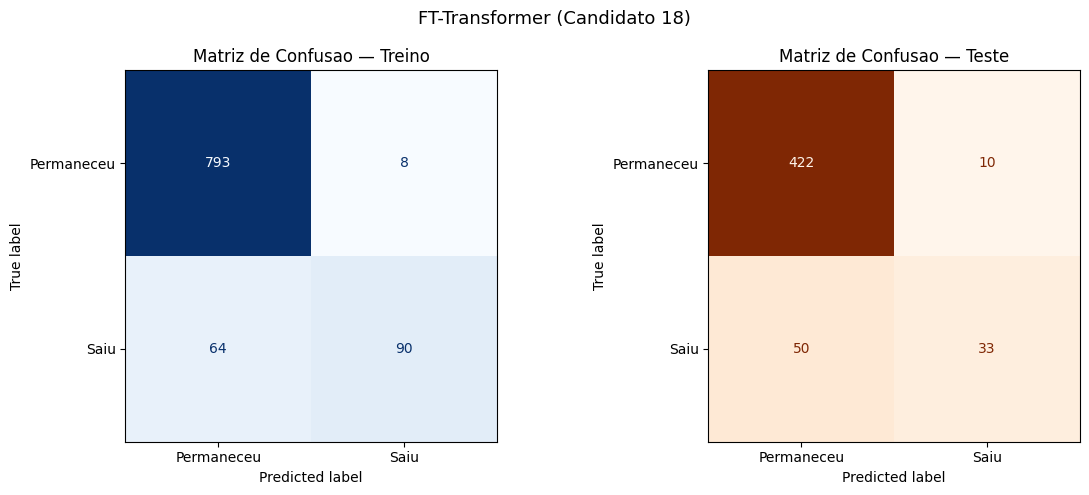

In [192]:
# 7. Visualização - matrizes de confusão (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("FT-Transformer (Candidato 18)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

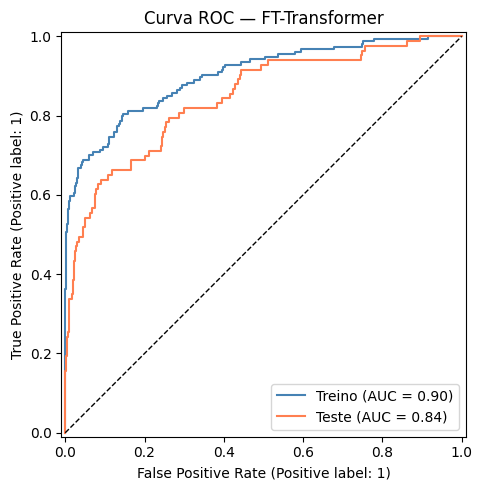

In [193]:
# 8. Visualizão - curva ROC (treino e teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train_g18, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g18,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — FT-Transformer")
plt.tight_layout()
plt.savefig("roc_curve_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

In [194]:
# 9. Análise da matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g18).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 422  OK
  FP — Permaneceu, previsto Saiu:       10  Erro
  FN — Saiu, previsto Permaneceu:       50  Erro (critico)
  TP — Saiu, previsto Saiu:             33  OK

  O modelo falhou em detetar 50 saidas reais (Falsos Negativos).


In [195]:
# 10. Resumo final
print("=" * 55)
print("RESUMO — CANDIDATO 18")
print("=" * 55)
print(f"  Algoritmo:         FT-Transformer (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g18) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 18
  Algoritmo:         FT-Transformer (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.7143
  F1 teste:  0.5238
  Baseline:  0.2483
  Melhoria:  +0.2755


# Tabela Final - Comparação de Modelos

In [196]:
# 1. Tabela Final - Comparação de Modelos

tabela_comparativa = pd.DataFrame([
    {"Modelo": "Baseline — Arvore de Decisao",
     "F1 Treino":        f1_score(y_train,        clf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 1 — Random Forest",
     "F1 Treino":        f1_score(y_train,        clf_rf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_rf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_rf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_rf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_rf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_rf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_rf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_rf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 2 — Gradient Boosting",
     "F1 Treino":        f1_score(y_train,        clf_gb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_gb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_gb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_gb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_gb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_gb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_gb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_gb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 3 — XGBoost",
     "F1 Treino":        f1_score(y_train,        clf_xgb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_xgb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_xgb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_xgb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_xgb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_xgb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_xgb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_xgb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 4 — LightGBM",
     "F1 Treino":        f1_score(y_train,        clf_lgbm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lgbm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lgbm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lgbm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lgbm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lgbm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lgbm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lgbm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 5 — CatBoost",
     "F1 Treino":        f1_score(y_train,        clf_cat.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_cat.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_cat.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_cat.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_cat.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_cat.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_cat.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_cat.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 6 — SVM",
     "F1 Treino":        f1_score(y_train,        pipeline_svm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_svm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_svm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_svm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_svm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_svm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_svm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_svm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 7 — Arvore com Pruning",
     "F1 Treino":        f1_score(y_train,        clf_pruned.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_pruned.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_pruned.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_pruned.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_pruned.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_pruned.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_pruned.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_pruned.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 8 — Regressao Logistica",
     "F1 Treino":        f1_score(y_train,        pipeline_lr.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_lr.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_lr.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_lr.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_lr.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_lr.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_lr.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_lr.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 9 — LDA",
     "F1 Treino":        f1_score(y_train,        clf_lda.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lda.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lda.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lda.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lda.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lda.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lda.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lda.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 10 — Naive Bayes",
     "F1 Treino":        f1_score(y_train,        clf_nb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_nb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_nb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_nb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_nb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_nb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_nb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_nb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 11 — KNN",
     "F1 Treino":        f1_score(y_train,        pipeline_knn.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_knn.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_knn.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_knn.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_knn.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_knn.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_knn.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_knn.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 12 — Extra Trees",
     "F1 Treino":        f1_score(y_train,        clf_et.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_et.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_et.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_et.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_et.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_et.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_et.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_et.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 13 — MLP",
     "F1 Treino":        f1_score(y_train,        pipeline_mlp.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_mlp.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_mlp.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_mlp.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_mlp.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_mlp.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_mlp.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_mlp.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 14 — TabNet",
     "F1 Treino":        f1_score(y_train_tab,        clf_tabnet.predict(X_train_tab)),
     "Precision Treino": precision_score(y_train_tab,  clf_tabnet.predict(X_train_tab)),
     "Recall Treino":    recall_score(y_train_tab,     clf_tabnet.predict(X_train_tab)),
     "AUC Treino":       roc_auc_score(y_train_tab,    clf_tabnet.predict_proba(X_train_tab)[:, 1]),
     "F1 Teste":         f1_score(y_test_tab,          clf_tabnet.predict(X_test_tab)),
     "Precision Teste":  precision_score(y_test_tab,   clf_tabnet.predict(X_test_tab)),
     "Recall Teste":     recall_score(y_test_tab,      clf_tabnet.predict(X_test_tab)),
     "AUC Teste":        roc_auc_score(y_test_tab,     clf_tabnet.predict_proba(X_test_tab)[:, 1])},

    {"Modelo": "Candidato 15 — Keras",
     "F1 Treino":        f1_score(y_train_keras,        (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Treino": precision_score(y_train_keras,  (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Treino":    recall_score(y_train_keras,     (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Treino":       roc_auc_score(y_train_keras,    model_keras.predict(X_train_keras, verbose=0).flatten()),
     "F1 Teste":         f1_score(y_test_keras,          (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Teste":  precision_score(y_test_keras,   (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Teste":     recall_score(y_test_keras,      (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Teste":        roc_auc_score(y_test_keras,     model_keras.predict(X_test_keras, verbose=0).flatten())},

    {"Modelo": "Candidato 16 — Keras Dropout+BN",
     "F1 Treino":        f1_score(y_train_k16,        y_pred_train_k16),
     "Precision Treino": precision_score(y_train_k16,  y_pred_train_k16),
     "Recall Treino":    recall_score(y_train_k16,     y_pred_train_k16),
     "AUC Treino":       roc_auc_score(y_train_k16,    y_proba_train_k16),
     "F1 Teste":         f1_score(y_test_k16,          y_pred_test_k16),
     "Precision Teste":  precision_score(y_test_k16,   y_pred_test_k16),
     "Recall Teste":     recall_score(y_test_k16,      y_pred_test_k16),
     "AUC Teste":        roc_auc_score(y_test_k16,     y_proba_test_k16)},

    {"Modelo": "Candidato 17 — GANDALF",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g17),
     "Precision Treino": precision_score(y_train,  y_pred_train_g17),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g17),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g17),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g17),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g17),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g17),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g17)},

    {"Modelo": "Candidato 18 — FT-Transformer",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g18),
     "Precision Treino": precision_score(y_train,  y_pred_train_g18),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g18),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g18),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g18),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g18),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g18),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g18)},
]).round(4)

# Coluna de overfitting
# Calcula e formata a coluna de overfitting com indicador visual
tabela_comparativa["Overfitting (F1)"] = (
    tabela_comparativa["F1 Treino"] - tabela_comparativa["F1 Teste"]
).round(4).apply(lambda x: f"{x:+.4f} " if x > 0.10 else f"{x:+.4f} Bom")

# Ordenar pelo F1 Teste
# Ordena pelo F1 Teste descendente para ver o melhor modelo no topo
tabela_comparativa = tabela_comparativa.sort_values("F1 Teste", ascending=False).reset_index(drop=True)

print("===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====")
display(tabela_comparativa)

# Modelo vencedor
# O modelo na primeira linha é o vencedor (maior F1 no teste)
melhor = tabela_comparativa.iloc[0]
print(f"\n  Modelo vencedor:   {melhor['Modelo']}")
print(f"  F1 Treino:         {melhor['F1 Treino']:.4f}")
print(f"  F1 Teste:          {melhor['F1 Teste']:.4f}")
print(f"  AUC-ROC Teste:     {melhor['AUC Teste']:.4f}")
print(f"  Overfitting (F1):  {melhor['Overfitting (F1)']}")

===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====


,Modelo,F1 Treino,Precision Treino,Recall Treino,AUC Treino,F1 Teste,Precision Teste,Recall Teste,AUC Teste,Overfitting (F1)
0,Candidato 8 — Regressao Logistica,0.6743,0.8224,0.5714,0.8895,0.5538,0.7660,0.4337,0.8236,+0.1205
1,Candidato 17 — GANDALF,0.7732,0.9043,0.6753,0.9507,0.5333,0.6923,0.4337,0.8192,+0.2399
2,Candidato 18 — FT-Transformer,0.7143,0.9184,0.5844,0.9014,0.5238,0.7674,0.3976,0.8449,+0.1905
3,Candidato 16 — Keras Dropout+BN,0.9902,1.0000,0.9805,0.9999,0.4853,0.6226,0.3976,0.7578,+0.5049
4,Candidato 15 — Keras,1.0000,1.0000,1.0000,1.0000,0.4828,0.5645,0.4217,0.7814,+0.5172
5,Candidato 13 — MLP,1.0000,1.0000,1.0000,1.0000,0.4789,0.5763,0.4096,0.7869,+0.5211
6,Candidato 9 — LDA,0.6512,0.8077,0.5455,0.8795,0.4651,0.6522,0.3614,0.8179,+0.1861
7,Candidato 10 — Naive Bayes,0.4766,0.3627,0.6948,0.8006,0.4400,0.3293,0.6627,0.7447,+0.0366 Bom
8,Candidato 3 — XGBoost,1.0000,1.0000,1.0000,1.0000,0.3621,0.6364,0.2530,0.7361,+0.6379
9,Candidato 2 — Gradient Boosting,0.9039,1.0000,0.8247,0.9966,0.3559,0.6000,0.2530,0.7791,+0.5480



  Modelo vencedor:   Candidato 8 — Regressao Logistica
  F1 Treino:         0.6743
  F1 Teste:          0.5538
  AUC-ROC Teste:     0.8236
  Overfitting (F1):  +0.1205 


In [197]:
# 2. Guarda a tabela comparativa em CSV para uso futuro (e.g., relatório, apresentação)
n_total = X_train.shape[0] + X_test.shape[0]
pct_treino = X_train.shape[0] / n_total * 100
pct_teste  = X_test.shape[0]  / n_total * 100
nome_ficheiro = f"tabela_comparativa_treino{pct_treino:.0f}_teste{pct_teste:.0f}.csv"
tabela_comparativa.to_csv(nome_ficheiro, index=False)
print(f"\n  Ficheiro guardado: {nome_ficheiro}")


  Ficheiro guardado: tabela_comparativa_treino65_teste35.csv


# Parte III — Modelo Campeão
## Regressão Logística Otimizada

O Candidato 8 apresentou os resultados baseline da Regressão Logística com parâmetros default.  
Esta secção aplica uma **pipeline de otimização sistemática** ao mesmo algoritmo:

1. **Pesquisa do Melhor Split** — 6 proporções testadas (65/35 a 90/10)
2. **Pesquisa do Melhor Normalizador** — StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
3. **Pesquisa da Melhor Variante de SMOTE** — 7 técnicas de resampling
4. **GridSearchCV** com StratifiedKFold (k=15) — penalizações L1, L2, ElasticNet
5. **Otimização de Threshold** — threshold ótimo para maximizar F1 (classe `Yes`)


## 1. Importações e Carregamento de Dados

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — pré-processamento
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler
)

from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Sklearn — modelo
from sklearn.linear_model import LogisticRegression

# Sklearn — métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)

# Imbalanced-learn — variantes de SMOTE
from imblearn.over_sampling import (
    SMOTE,
    SMOTENC,
    BorderlineSMOTE,
    SVMSMOTE,
    ADASYN
)

from imblearn.combine import (
    SMOTETomek,
    SMOTEENN
)

from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

print('Importações concluídas')

Importações concluídas


In [199]:
#  Carregamento do dataset 

# URL do dataset no GitHub
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'\nDistribuição do Target:')
print(df['Attrition'].value_counts())
# O rácio mostra quantas vezes há mais 'No' do que 'Yes'
# Um rácio elevado (ex: 5:1) justifica o uso de técnicas como SMOTE
print(f'\nRácio de desequilíbrio: {df["Attrition"].value_counts()["No"] / df["Attrition"].value_counts()["Yes"]:.1f}:1')

Shape: (1470, 62)

Distribuição do Target:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Rácio de desequilíbrio: 5.2:1


## 2. Pré-processamento

In [200]:
# Remove colunas categóricas e o target original
# Ficamos só com variáveis numéricas e Attrition_bin como target
cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]
# Remove colunas categóricas e o target original
# Ficamos só com variáveis numéricas e Attrition_bin como target
cols_remover = [c for c in cols_remover if c in df.columns]
df = df.drop(columns=cols_remover)

#  Separação Features / Target 
# Separa features (X) e target (y)
X = df.drop(columns=['Attrition_bin'])
y = df['Attrition_bin']

print(f'\nFeatures: {X.shape[1]} colunas')
print(f'Target — Yes (1): {y.sum()} | No (0): {(y == 0).sum()}')


Features: 53 colunas
Target — Yes (1): 237 | No (0): 1233


## 3. Pesquisa do Melhor Split

Testamos 6 proporções de divisão treino/teste, mantendo o mesmo normalizador base (StandardScaler) e sem SMOTE, para isolar o efeito do split.

In [201]:
# Proporções do conjunto de teste a testar
splits = [0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
split_labels = ['65/35', '70/30', '75/25', '80/20', '85/15', '90/10']

split_results = []

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_yes': 'f1',
    'f1_macro': 'f1_macro',
    'precision_yes': 'precision',
    'recall_yes': 'recall',
    'auc_roc': 'roc_auc'
}

for test_size, label in zip(splits, split_labels):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    pipeline_split = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_split,
        X_tr,
        y_tr,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    split_results.append({
        'Split': label,
        'Treino': len(X_tr),
        'Teste': len(X_te),
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4),
        'Desvio Padrão F1': round(scores['test_f1_yes'].std(), 4)
    })

df_splits = pd.DataFrame(split_results)
print('Comparação de Splits com Validação Cruzada:')
print(df_splits.to_string(index=False))

best_split_row = df_splits.loc[df_splits['F1 Yes'].idxmax()]
BEST_SPLIT_LABEL = best_split_row['Split']
BEST_TEST_SIZE = splits[split_labels.index(BEST_SPLIT_LABEL)]

print(f'Melhor split: {BEST_SPLIT_LABEL} (F1 Yes CV = {best_split_row["F1 Yes"]})')


Comparação de Splits com Validação Cruzada:
Split  Treino  Teste  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC  Desvio Padrão F1
65/35     955    515  0.5530    0.7141      0.7279         0.4615   0.8304            0.0823
70/30    1029    441  0.5281    0.6984      0.7116         0.4224   0.8350            0.0684
75/25    1102    368  0.5156    0.6869      0.7177         0.4053   0.8389            0.0745
80/20    1176    294  0.4978    0.6746      0.6949         0.3905   0.8323            0.0688
85/15    1249    221  0.5150    0.6864      0.7271         0.4014   0.8283            0.0834
90/10    1323    147  0.5191    0.6911      0.7102         0.4144   0.8349            0.0726
Melhor split: 65/35 (F1 Yes CV = 0.553)


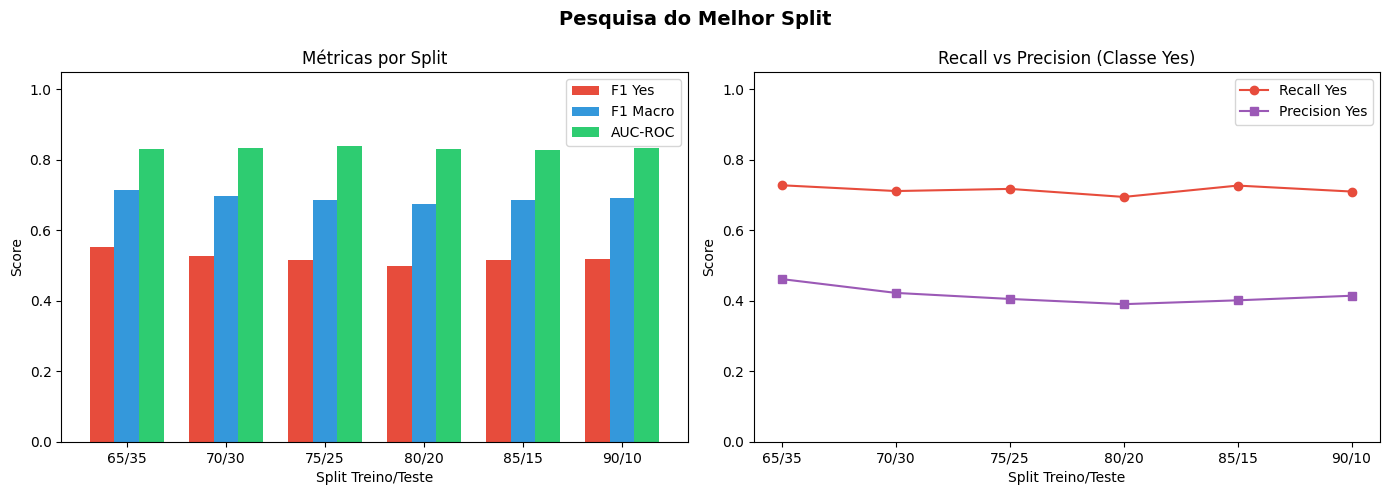

 Guardado: split_search.png


In [202]:
#  Visualização dos resultados de split 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 por split
ax = axes[0]
x = np.arange(len(split_labels))
w = 0.25
ax.bar(x - w, df_splits['F1 Yes'],   w, label='F1 Yes',   color='#e74c3c')
ax.bar(x,     df_splits['F1 Macro'], w, label='F1 Macro', color='#3498db')
ax.bar(x + w, df_splits['AUC-ROC'],  w, label='AUC-ROC',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.set_xlabel('Split Treino/Teste')
ax.set_ylabel('Score')
ax.set_title('Métricas por Split')
ax.legend()
ax.set_ylim(0, 1.05)

# Recall vs Precision
ax2 = axes[1]
ax2.plot(split_labels, df_splits['Recall Yes'],    marker='o', label='Recall Yes',    color='#e74c3c')
ax2.plot(split_labels, df_splits['Precision Yes'], marker='s', label='Precision Yes', color='#9b59b6')
ax2.set_xlabel('Split Treino/Teste')
ax2.set_ylabel('Score')
ax2.set_title('Recall vs Precision (Classe Yes)')
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.suptitle('Pesquisa do Melhor Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('split_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: split_search.png')

## 4. Pesquisa do Melhor Normalizador

Usando o melhor split encontrado, testamos 4 estratégias de normalização:
- **StandardScaler** — média 0, desvio padrão 1 (sensível a outliers)
- **MinMaxScaler** — escala [0,1] (preserva distribuição)
- **RobustScaler** — baseado em mediana/IQR (robusto a outliers)
- **MaxAbsScaler** — escala [-1,1] sem centrar (preserva esparsidade)

In [203]:
# Split com o melhor valor encontrado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=BEST_TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
    'MaxAbsScaler':   MaxAbsScaler()
}

scaler_results = []

for name, scaler in scalers.items():
    pipeline_scaler = ImbPipeline([
        ('scaler', scaler.__class__()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_scaler,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    scaler_results.append({
        'Normalizador': name,
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4)
    })

df_scalers = pd.DataFrame(scaler_results)
print('Comparação de Normalizadores com Validação Cruzada:')
print(df_scalers.to_string(index=False))

best_scaler_row = df_scalers.loc[df_scalers['F1 Yes'].idxmax()]
BEST_SCALER_NAME = best_scaler_row['Normalizador']
BEST_SCALER = scalers[BEST_SCALER_NAME]

print(f'Melhor normalizador: {BEST_SCALER_NAME} (F1 Yes CV = {best_scaler_row["F1 Yes"]})')


Comparação de Normalizadores com Validação Cruzada:
  Normalizador  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC
StandardScaler  0.5530    0.7141      0.7279         0.4615   0.8304
  MinMaxScaler  0.5399    0.7056      0.7158         0.4477   0.8342
  RobustScaler  0.5282    0.6959      0.7218         0.4237   0.8276
  MaxAbsScaler  0.5222    0.6914      0.7091         0.4254   0.8325
Melhor normalizador: StandardScaler (F1 Yes CV = 0.553)


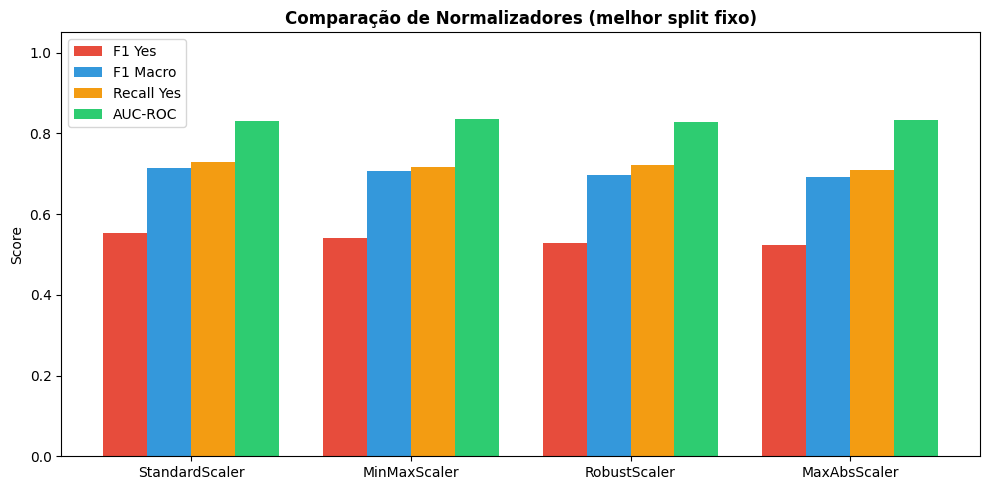

 Guardado: scaler_search.png


In [204]:
#  Visualização normalizadores 
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_scalers))
w = 0.2
ax.bar(x - 1.5*w, df_scalers['F1 Yes'],       w, label='F1 Yes',       color='#e74c3c')
ax.bar(x - 0.5*w, df_scalers['F1 Macro'],     w, label='F1 Macro',     color='#3498db')
ax.bar(x + 0.5*w, df_scalers['Recall Yes'],   w, label='Recall Yes',   color='#f39c12')
ax.bar(x + 1.5*w, df_scalers['AUC-ROC'],      w, label='AUC-ROC',      color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(df_scalers['Normalizador'])
ax.set_ylabel('Score')
ax.set_title('Comparação de Normalizadores (melhor split fixo)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('scaler_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: scaler_search.png')

## 5. Pesquisa da Melhor Variante de SMOTE

Usando o melhor split e melhor normalizador, testamos 7 estratégias de oversampling/resampling:

| Técnica | Descrição |
|---|---|
| **SMOTE** | Síntese de amostras por interpolação KNN clássica |
| **BorderlineSMOTE** | Foca nos exemplos na fronteira de decisão |
| **SVMSMOTE** | Usa SVM para identificar as amostras de suporte |
| **ADASYN** | Adapta a densidade — mais sintéticos nas zonas difíceis |
| **SMOTETomek** | SMOTE + remoção de pares Tomek (limpeza) |
| **SMOTEENN** | SMOTE + ENN (limpeza mais agressiva) |
| **Sem SMOTE** | Apenas `class_weight='balanced'` (baseline de comparação) |

In [205]:
# Dicionário com as variantes de resampling a comparar
# 'passthrough' = sem resampling
smote_variants = {
    'Sem SMOTE':       'passthrough',
    'SMOTE':           SMOTE(random_state=RANDOM_STATE),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=RANDOM_STATE),
    'SVMSMOTE':        SVMSMOTE(random_state=RANDOM_STATE),
    'ADASYN':          ADASYN(random_state=RANDOM_STATE),
    'SMOTETomek':      SMOTETomek(random_state=RANDOM_STATE),
    'SMOTEENN':        SMOTEENN(random_state=RANDOM_STATE)
}

smote_results = []

for name, sampler in smote_variants.items():
    sampler_step = 'passthrough' if sampler == 'passthrough' else sampler.__class__(random_state=RANDOM_STATE)

    pipeline_smote = ImbPipeline([
        ('scaler', scalers[BEST_SCALER_NAME].__class__()),
        ('smote', sampler_step),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_smote,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    smote_results.append({
        'Técnica': name,
        'Amostras Treino': len(X_train),
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4)
    })

df_smote = pd.DataFrame(smote_results)
print('Comparação de Técnicas de Resampling com Validação Cruzada:')
print(df_smote.to_string(index=False))

best_smote_row = df_smote.loc[df_smote['F1 Yes'].idxmax()]
BEST_SMOTE_NAME = best_smote_row['Técnica']
BEST_SMOTE = smote_variants[BEST_SMOTE_NAME]

print(f'Melhor técnica: {BEST_SMOTE_NAME} (F1 Yes CV = {best_smote_row["F1 Yes"]})')


Comparação de Técnicas de Resampling com Validação Cruzada:
        Técnica  Amostras Treino  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC
      Sem SMOTE              955  0.5154    0.6823      0.7224         0.4125   0.8296
          SMOTE              955  0.5530    0.7141      0.7279         0.4615   0.8304
BorderlineSMOTE              955  0.5557    0.7206      0.6958         0.4779   0.8362
       SVMSMOTE              955  0.5693    0.7323      0.6758         0.5107   0.8382
         ADASYN              955  0.5203    0.6882      0.7091         0.4228   0.8283
     SMOTETomek              955  0.5521    0.7133      0.7279         0.4604   0.8303
       SMOTEENN              955  0.4800    0.6440      0.7861         0.3517   0.8127
Melhor técnica: SVMSMOTE (F1 Yes CV = 0.5693)


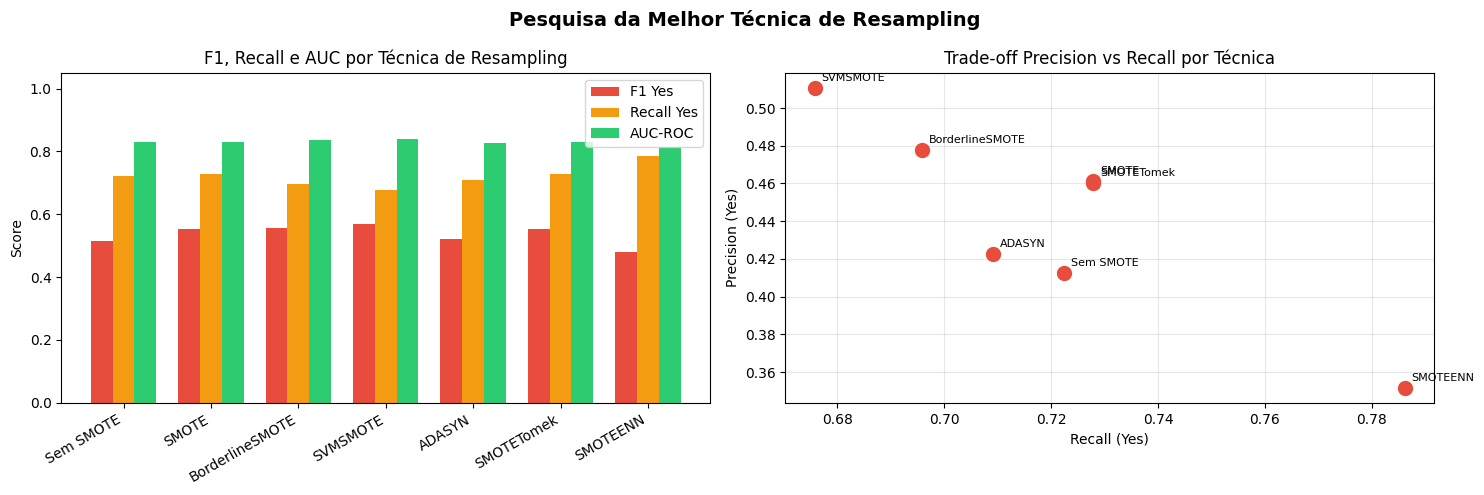

 Guardado: smote_search.png


In [206]:
#  Visualização SMOTE 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1, Recall, AUC por técnica
ax = axes[0]
x = np.arange(len(df_smote))
w = 0.25
ax.bar(x - w, df_smote['F1 Yes'],     w, label='F1 Yes',     color='#e74c3c')
ax.bar(x,     df_smote['Recall Yes'], w, label='Recall Yes', color='#f39c12')
ax.bar(x + w, df_smote['AUC-ROC'],   w, label='AUC-ROC',    color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(df_smote['Técnica'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('F1, Recall e AUC por Técnica de Resampling')
ax.legend()
ax.set_ylim(0, 1.05)

# Precision vs Recall
ax2 = axes[1]
ax2.scatter(df_smote['Recall Yes'], df_smote['Precision Yes'],
            s=100, zorder=5, color='#e74c3c')
for _, row in df_smote.iterrows():
    ax2.annotate(row['Técnica'],
                 (row['Recall Yes'], row['Precision Yes']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax2.set_xlabel('Recall (Yes)')
ax2.set_ylabel('Precision (Yes)')
ax2.set_title('Trade-off Precision vs Recall por Técnica')
ax2.grid(True, alpha=0.3)

plt.suptitle('Pesquisa da Melhor Técnica de Resampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: smote_search.png')

## 6. Modelo Final Otimizado

Com a combinação ótima encontrada (melhor split + melhor normalizador + melhor SMOTE), aplicamos:
- **GridSearchCV** para afinar os hiperparâmetros da Regressão Logística
- **StratifiedKFold (k=15)** para garantir robustez dos resultados

In [207]:
# Resume a configuração ótima encontrada nas 3 pesquisas anteriores
print("\n=== Melhor configuração ===")
print(f"Split        : {BEST_SPLIT_LABEL}")
print(f"Normalização : {BEST_SCALER_NAME}")
print(f"Resampling   : {BEST_SMOTE_NAME}")


=== Melhor configuração ===
Split        : 65/35
Normalização : StandardScaler
Resampling   : SVMSMOTE


In [208]:
# Preparação final dos dados

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y, test_size=BEST_TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

sampler_final = (
    'passthrough'
    if BEST_SMOTE_NAME == 'Sem SMOTE'
    else smote_variants[BEST_SMOTE_NAME].__class__(random_state=RANDOM_STATE)
)

pipeline_final = ImbPipeline([
    ('scaler', scalers[BEST_SCALER_NAME].__class__()),
    ('smote', sampler_final),
    ('model', LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))
])

print(f'Treino final: {len(X_train_f)} amostras')
print(f'Teste final:  {len(X_test_f)} amostras')
print(f'  Yes treino (1): {y_train_f.sum()} | No treino (0): {(y_train_f == 0).sum()}')
print(f'  Yes teste  (1): {y_test_f.sum()} | No teste  (0): {(y_test_f == 0).sum()}')


Treino final: 955 amostras
Teste final:  515 amostras
  Yes treino (1): 154 | No treino (0): 801
  Yes teste  (1): 83 | No teste  (0): 432


In [209]:
# GridSearchCV

param_grid = [
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['l1'],
        'model__solver': ['saga'],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['l2'],
        'model__solver': ['saga'],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': [0.1, 0.5, 0.9],
        'model__class_weight': ['balanced']
    }
]

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline_final,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_f, y_train_f)

print(f'ridSearchCV concluído')
print(f'   Melhores parâmetros: {grid_search.best_params_}')
print(f'   Melhor F1 (CV treino): {grid_search.best_score_:.4f}')


Fitting 15 folds for each of 45 candidates, totalling 675 fits
ridSearchCV concluído
   Melhores parâmetros: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}
   Melhor F1 (CV treino): 0.5800


In [210]:
# Cross-Validation no conjunto de treino com modelo final

best_model = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train_f,
    y_train_f,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print(f'Cross-Validation — F1 Yes:')
print(f'   Scores por fold: {[round(s,4) for s in cv_scores]}')
print(f'   Média:           {cv_scores.mean():.4f}')
print(f'   Desvio Padrão:   {cv_scores.std():.4f}')

# Avaliação inicial no teste com threshold padrão de 0.5
y_pred_f = best_model.predict(X_test_f)
y_prob_f = best_model.predict_proba(X_test_f)[:, 1]

print(f'Avaliação no Conjunto de Teste — threshold 0.5:')
print(classification_report(y_test_f, y_pred_f, target_names=['No (0)', 'Yes (1)']))

import warnings
warnings.filterwarnings('ignore', category=UserWarning)


Cross-Validation — F1 Yes:
   Scores por fold: [np.float64(0.4615), np.float64(0.56), np.float64(0.6087), np.float64(0.75), np.float64(0.6316), np.float64(0.6), np.float64(0.5185), np.float64(0.56), np.float64(0.4615), np.float64(0.5806), np.float64(0.5882), np.float64(0.6923), np.float64(0.6154), np.float64(0.5), np.float64(0.5714)]
   Média:           0.5800
   Desvio Padrão:   0.0756
Avaliação no Conjunto de Teste — threshold 0.5:
              precision    recall  f1-score   support

      No (0)       0.92      0.84      0.88       432
     Yes (1)       0.43      0.61      0.50        83

    accuracy                           0.81       515
   macro avg       0.67      0.73      0.69       515
weighted avg       0.84      0.81      0.82       515



## 7. Avaliação Final do Modelo

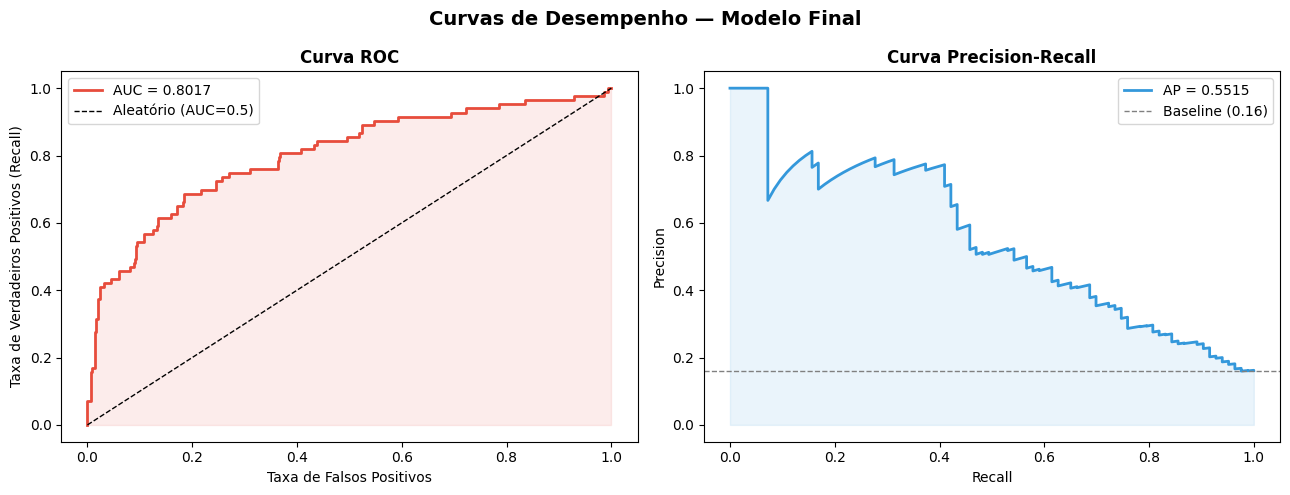

 Guardado: roc_pr_curves_final.png


In [211]:
#  Curva ROC 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
# Calcula os pontos da curva ROC: taxa de falsos positivos vs taxa de verdadeiros positivos
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)
# AUC = área sob a curva ROC; 1.0 = perfeito, 0.5 = aleatório
auc_val = roc_auc_score(y_test_f, y_prob_f)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Aleatório (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()

# Precision-Recall
# Curva Precision-Recall: especialmente útil para datasets desequilibrados
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test_f, y_prob_f)
# AP (Average Precision) = área sob a curva PR; equivalente ao AUC mas para PR
ap = average_precision_score(y_test_f, y_prob_f)
axes[1].plot(recall_curve, precision_curve, color='#3498db', lw=2, label=f'AP = {ap:.4f}')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='#3498db')
axes[1].axhline(y_test_f.mean(), color='gray', linestyle='--', lw=1, label=f'Baseline ({y_test_f.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend()

plt.suptitle('Curvas de Desempenho — Modelo Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: roc_pr_curves_final.png')

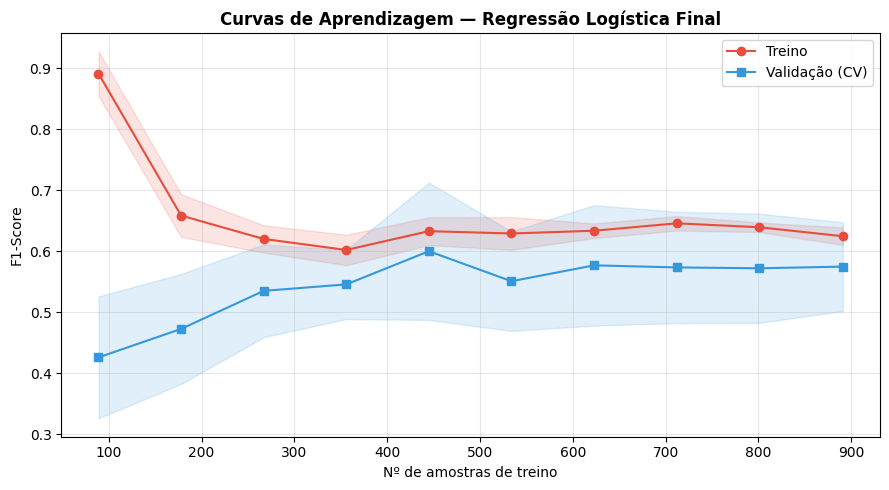

 Guardado: learning_curves_final.png


In [212]:
# Curvas de Aprendizagem

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_f,
    y_train_f,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, val_mean, 's-', color='#3498db', label='Validação (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
plt.xlabel('Nº de amostras de treino')
plt.ylabel('F1-Score')
plt.title('Curvas de Aprendizagem — Regressão Logística Final', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: learning_curves_final.png')


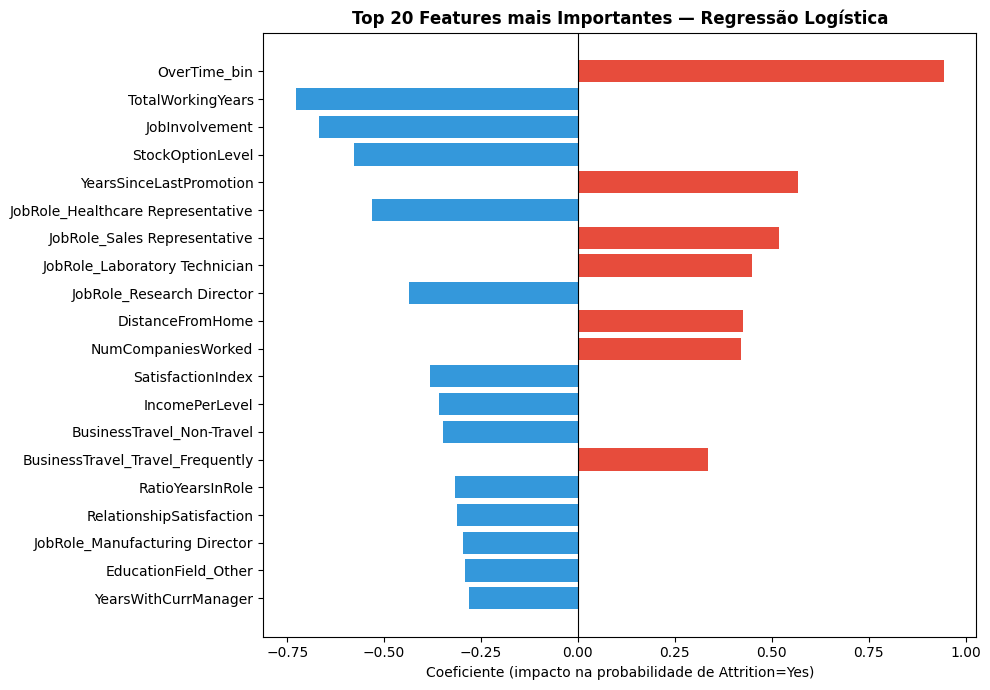

Top 10 features:
                          Feature  Coeficiente
                     OverTime_bin     0.944134
                TotalWorkingYears    -0.728135
                   JobInvolvement    -0.667947
                 StockOptionLevel    -0.577758
          YearsSinceLastPromotion     0.568629
JobRole_Healthcare Representative    -0.532131
     JobRole_Sales Representative     0.517500
    JobRole_Laboratory Technician     0.450194
        JobRole_Research Director    -0.434513
                 DistanceFromHome     0.425887
 Guardado: feature_importance_final.png


In [213]:
# Feature Importance (Coeficientes)

modelo_lr = best_model.named_steps['model']

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_lr.coef_[0],
    'Abs': np.abs(modelo_lr.coef_[0])
}).sort_values('Abs', ascending=False)

top_n = 20
top_coef = coef_df.head(top_n)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coef['Coeficiente']]
plt.barh(top_coef['Feature'][::-1], top_coef['Coeficiente'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (impacto na probabilidade de Attrition=Yes)')
plt.title(f'Top {top_n} Features mais Importantes — Regressão Logística', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top 10 features:')
print(coef_df[['Feature', 'Coeficiente']].head(10).to_string(index=False))
print(' Guardado: feature_importance_final.png')


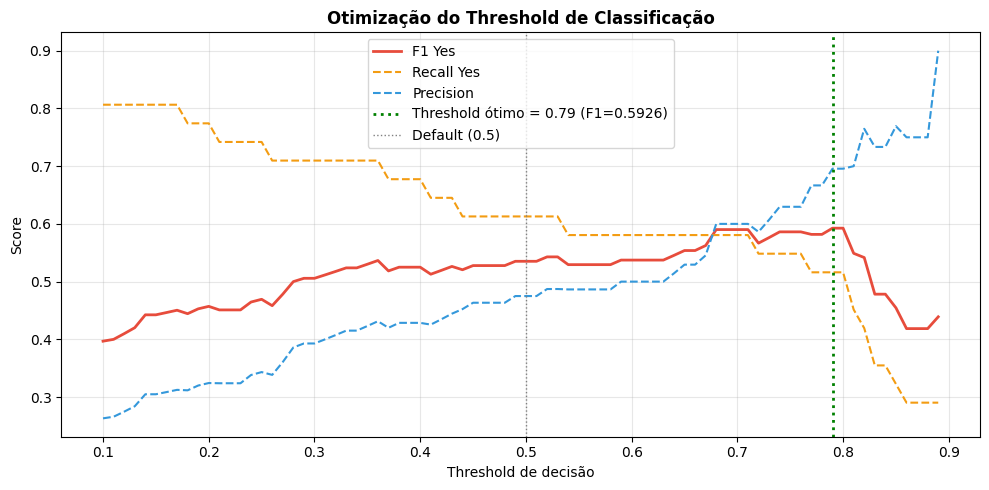

Threshold ótimo: 0.79
   F1 Yes com threshold padrão (0.5): 0.5050
   F1 Yes com threshold ótimo (0.79): 0.5147
 Guardado: threshold_optimization.png


In [214]:
# Otimização de Threshold

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_f,
    y_train_f,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_f
)

threshold_model = clone(grid_search.best_estimator_)
threshold_model.fit(X_train_sub, y_train_sub)

y_prob_val = threshold_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_thresh = []
recall_thresh = []
prec_thresh = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    f1_scores_thresh.append(f1_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    recall_thresh.append(recall_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    prec_thresh.append(precision_score(y_val, y_pred_t, pos_label=1, zero_division=0))

best_thresh_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_thresh_idx]
best_f1_thresh = f1_scores_thresh[best_thresh_idx]

# Reajusta o modelo final em todo o conjunto de treino após escolher o threshold
best_model = clone(grid_search.best_estimator_)
best_model.fit(X_train_f, y_train_f)

y_prob_f = best_model.predict_proba(X_test_f)[:, 1]
y_pred_f = best_model.predict(X_test_f)
y_pred_opt = (y_prob_f >= best_threshold).astype(int)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores_thresh, label='F1 Yes', color='#e74c3c', lw=2)
plt.plot(thresholds, recall_thresh, label='Recall Yes', color='#f39c12', lw=1.5, linestyle='--')
plt.plot(thresholds, prec_thresh, label='Precision', color='#3498db', lw=1.5, linestyle='--')
plt.axvline(best_threshold, color='green', linestyle=':', lw=2,
            label=f'Threshold ótimo = {best_threshold:.2f} (F1={best_f1_thresh:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', lw=1, label='Default (0.5)')
plt.xlabel('Threshold de decisão')
plt.ylabel('Score')
plt.title('Otimização do Threshold de Classificação', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold ótimo: {best_threshold:.2f}')
print(f'   F1 Yes com threshold padrão (0.5): {f1_score(y_test_f, y_pred_f, pos_label=1):.4f}')
print(f'   F1 Yes com threshold ótimo ({best_threshold:.2f}): {f1_score(y_test_f, y_pred_opt, pos_label=1):.4f}')
print(' Guardado: threshold_optimization.png')


## 7.2 Comparação Treino vs Teste

Análise do comportamento do modelo nos dados de treino (Cross-Validation 15-Fold sobre dados SMOTE) versus o conjunto de teste real (distribuição original, 85/15).

In [215]:
# MÉTRICAS NO TREINO

# Previsões no conjunto de treino apenas para análise descritiva
# O F1 médio da validação cruzada continua a ser a métrica mais fiável para treino
y_proba_train_f = best_model.predict_proba(X_train_f)[:, 1]
y_pred_train_f = (y_proba_train_f >= best_threshold).astype(int)

print('===== MÉTRICAS — TREINO =====')
print(f'  F1-Score (CV médio): {cv_scores.mean():.4f}')
print(f'  Desvio Padrão:       {cv_scores.std():.4f}')
print(f'  Scores por fold:     {[round(s,4) for s in cv_scores]}')
print()
print(classification_report(y_train_f, y_pred_train_f, target_names=['Permaneceu (No)', 'Saiu (Yes)']))

===== MÉTRICAS — TREINO =====
  F1-Score (CV médio): 0.5800
  Desvio Padrão:       0.0756
  Scores por fold:     [np.float64(0.4615), np.float64(0.56), np.float64(0.6087), np.float64(0.75), np.float64(0.6316), np.float64(0.6), np.float64(0.5185), np.float64(0.56), np.float64(0.4615), np.float64(0.5806), np.float64(0.5882), np.float64(0.6923), np.float64(0.6154), np.float64(0.5), np.float64(0.5714)]

                 precision    recall  f1-score   support

Permaneceu (No)       0.91      0.97      0.94       801
     Saiu (Yes)       0.77      0.49      0.60       154

       accuracy                           0.89       955
      macro avg       0.84      0.73      0.77       955
   weighted avg       0.89      0.89      0.88       955



In [216]:
# MÉTRICAS NO TESTE

y_pred_test_f = y_pred_opt
y_proba_test_f = y_prob_f

print('===== MÉTRICAS — TESTE =====')
print(f'  Threshold:   {best_threshold:.2f}')
print(f'  F1-Score:    {f1_score(y_test_f, y_pred_test_f):.4f}')
print(f'  Precision:   {precision_score(y_test_f, y_pred_test_f):.4f}')
print(f'  Recall:      {recall_score(y_test_f, y_pred_test_f):.4f}')
print(f'  AUC-ROC:     {roc_auc_score(y_test_f, y_proba_test_f):.4f}')
print()
print(classification_report(y_test_f, y_pred_test_f, target_names=['Permaneceu (No)', 'Saiu (Yes)']))


===== MÉTRICAS — TESTE =====
  Threshold:   0.79
  F1-Score:    0.5147
  Precision:   0.6604
  Recall:      0.4217
  AUC-ROC:     0.8017

                 precision    recall  f1-score   support

Permaneceu (No)       0.90      0.96      0.93       432
     Saiu (Yes)       0.66      0.42      0.51        83

       accuracy                           0.87       515
      macro avg       0.78      0.69      0.72       515
   weighted avg       0.86      0.87      0.86       515



In [217]:
# TABELA COMPARATIVA TREINO vs TESTE

resultados_lr_final = pd.DataFrame({
    'Conjunto':  ['Treino', 'Teste'],
    'F1-Score':  [round(f1_score(y_train_f, y_pred_train_f), 4), round(f1_score(y_test_f, y_pred_test_f), 4)],
    'Precision': [round(precision_score(y_train_f, y_pred_train_f), 4), round(precision_score(y_test_f, y_pred_test_f), 4)],
    'Recall':    [round(recall_score(y_train_f, y_pred_train_f), 4), round(recall_score(y_test_f, y_pred_test_f), 4)],
    'AUC-ROC':   [round(roc_auc_score(y_train_f, y_proba_train_f), 4), round(roc_auc_score(y_test_f, y_proba_test_f), 4)],
})

print('===== TABELA COMPARATIVA TREINO vs TESTE =====')
display(resultados_lr_final)

diff = cv_scores.mean() - f1_score(y_test_f, y_pred_test_f)
print(f'Diferença F1 CV treino - teste: {diff:.4f}')
if diff > 0.10:
    print('  --> Possível sinal de overfitting: o desempenho médio em CV é superior ao desempenho no teste.')
else:
    print('  --> Sem sinais evidentes de overfitting.')


===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.5976,0.7732,0.4870,0.8860
1,Teste,0.5147,0.6604,0.4217,0.8017


Diferença F1 CV treino - teste: 0.0653
  --> Sem sinais evidentes de overfitting.


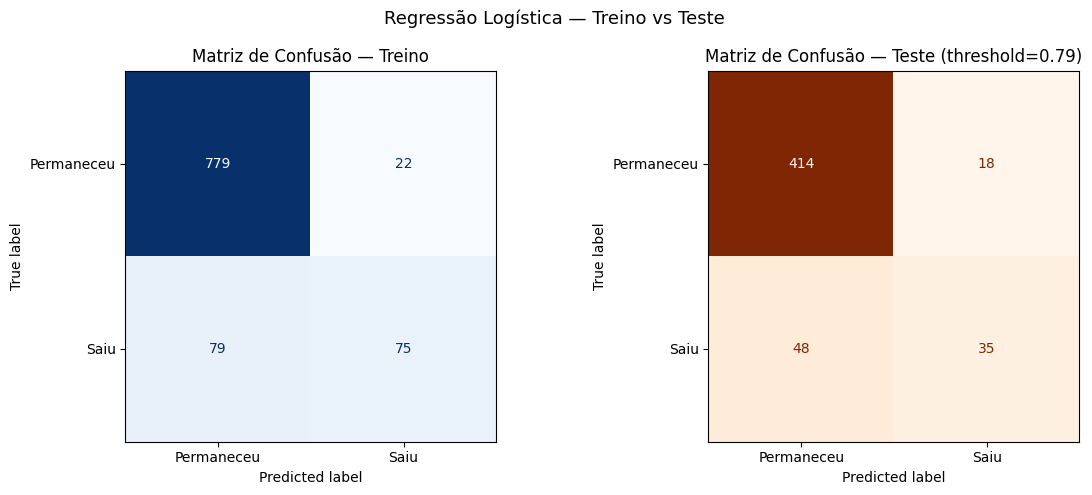

Guardado: confusion_matrix_treino_vs_teste.png


In [218]:
# MATRIZES DE CONFUSÃO — TREINO vs TESTE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_f, y_pred_train_f),
    display_labels=['Permaneceu', 'Saiu']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Treino')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_f, y_pred_test_f),
    display_labels=['Permaneceu', 'Saiu']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Matriz de Confusão — Teste (threshold={best_threshold:.2f})')

fig.suptitle('Regressão Logística — Treino vs Teste', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_treino_vs_teste.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: confusion_matrix_treino_vs_teste.png')


## 8. Resumo Final e Conclusão

In [219]:
# TABELA DE PROGRESSÃO DO MODELO

y_pred_opt = (y_prob_f >= best_threshold).astype(int)

summary = pd.DataFrame([
    {
        'Modelo': 'Baseline (Log. Reg. default)',
        'Split': '80/20', 'Normalizador': 'StandardScaler',
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': df_splits.loc[df_splits['Split']=='80/20','F1 Yes'].values[0],
        'AUC-ROC': df_splits.loc[df_splits['Split']=='80/20','AUC-ROC'].values[0]
    },
    {
        'Modelo': f'Melhor Split ({BEST_SPLIT_LABEL})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': 'StandardScaler',
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': best_split_row['F1 Yes'],
        'AUC-ROC': best_split_row['AUC-ROC']
    },
    {
        'Modelo': f'+ Melhor Normalizador ({BEST_SCALER_NAME})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': best_scaler_row['F1 Yes'],
        'AUC-ROC': best_scaler_row['AUC-ROC']
    },
    {
        'Modelo': f'+ Melhor SMOTE ({BEST_SMOTE_NAME})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': 0.5,
        'F1 Yes': best_smote_row['F1 Yes'],
        'AUC-ROC': best_smote_row['AUC-ROC']
    },
    {
        'Modelo': '+ GridSearchCV (threshold 0.5)',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': 0.5,
        'F1 Yes': round(f1_score(y_test_f, y_pred_f, pos_label=1), 4),
        'AUC-ROC': round(roc_auc_score(y_test_f, y_prob_f), 4)
    },
    {
        'Modelo': f'MODELO FINAL (threshold={best_threshold:.2f})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': best_threshold,
        'F1 Yes': round(f1_score(y_test_f, y_pred_opt, pos_label=1), 4),
        'AUC-ROC': round(roc_auc_score(y_test_f, y_prob_f), 4)
    },
])

print('' + '═'*100)
print('  TABELA COMPARATIVA COMPLETA — PROGRESSÃO DO MODELO')
print('═'*100)
print(summary.to_string(index=False))
print('═'*100)


════════════════════════════════════════════════════════════════════════════════════════════════════
  TABELA COMPARATIVA COMPLETA — PROGRESSÃO DO MODELO
════════════════════════════════════════════════════════════════════════════════════════════════════
                                Modelo Split   Normalizador Resampling  Threshold  F1 Yes  AUC-ROC
          Baseline (Log. Reg. default) 80/20 StandardScaler SMOTE base       0.50  0.4978   0.8323
                  Melhor Split (65/35) 65/35 StandardScaler SMOTE base       0.50  0.5530   0.8304
+ Melhor Normalizador (StandardScaler) 65/35 StandardScaler SMOTE base       0.50  0.5530   0.8304
             + Melhor SMOTE (SVMSMOTE) 65/35 StandardScaler   SVMSMOTE       0.50  0.5693   0.8382
        + GridSearchCV (threshold 0.5) 65/35 StandardScaler   SVMSMOTE       0.50  0.5050   0.8017
         MODELO FINAL (threshold=0.79) 65/35 StandardScaler   SVMSMOTE       0.79  0.5147   0.8017
════════════════════════════════════════════════════

In [220]:
# Relatório completo do modelo final com threshold otimizado
print("\n=== Relatório final ===")
print("Threshold otimizado aplicado\n")

print(classification_report(
    y_test_f, 
    y_pred_opt, 
    target_names=['No (0)', 'Yes (1)']
))

# Mostra os hiperparâmetros escolhidos pelo GridSearchCV
print("Parâmetros do modelo:")
print(grid_search.best_params_)


=== Relatório final ===
Threshold otimizado aplicado

              precision    recall  f1-score   support

      No (0)       0.90      0.96      0.93       432
     Yes (1)       0.66      0.42      0.51        83

    accuracy                           0.87       515
   macro avg       0.78      0.69      0.72       515
weighted avg       0.86      0.87      0.86       515

Parâmetros do modelo:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}


In [221]:
# EXPRESSÃO DO MODELO FINAL

modelo_lr = best_model.named_steps['model']

coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values('Coeficiente', ascending=False)

interceto = modelo_lr.intercept_[0]

print('Expressão do modelo:')
print(f'logit(p) = {interceto:.6f}', end=' ')

for _, row in coeficientes.iterrows():
    sinal = '+' if row['Coeficiente'] >= 0 else '-'
    print(f'{sinal} {abs(row["Coeficiente"]):.6f}*{row["Feature"]}', end=' ')

print('Probabilidade:')
print('p = 1 / (1 + exp(-logit(p)))')

print('Threshold final:')
print(f'Se p >= {best_threshold:.2f}, então prevê Attrition = Yes')
print(f'Se p < {best_threshold:.2f}, então prevê Attrition = No')


Expressão do modelo:
logit(p) = -1.871048 + 0.944134*OverTime_bin + 0.568629*YearsSinceLastPromotion + 0.517500*JobRole_Sales Representative + 0.450194*JobRole_Laboratory Technician + 0.425887*DistanceFromHome + 0.419721*NumCompaniesWorked + 0.336807*BusinessTravel_Travel_Frequently + 0.278695*MonthlyIncome + 0.229722*Gender_bin + 0.226127*MaritalStatus_Single + 0.209599*JobRole_Sales Executive + 0.182942*JobRole_Human Resources + 0.161853*EducationField_Human Resources + 0.159507*EducationField_Marketing + 0.124422*EducationField_Technical Degree + 0.108747*PercentSalaryHike + 0.102351*MonthlyRate + 0.050106*Department_Research & Development + 0.020261*CareerStagnation + 0.018474*JobLevel + 0.014983*EducationField_Medical + 0.001405*Department_Sales + 0.000147*JobRole_Manager - 0.002178*Education - 0.042823*BusinessTravel_Travel_Rarely - 0.055297*YearsInCurrentRole - 0.101136*MaritalStatus_Married - 0.106988*EducationField_Life Sciences - 0.114163*YearsAtCompany - 0.126001*Department_

## Conclusão

O modelo final de **Regressão Logística** foi construído em três etapas de pesquisa sistemática:

1. **Pesquisa de Split** — testámos 6 proporções (65/35 a 90/10). O split que maximizou o F1 na classe `Yes` foi selecionado para todas as fases seguintes.

2. **Pesquisa de Normalizador** — comparámos StandardScaler, MinMaxScaler, RobustScaler e MaxAbsScaler. A regressão logística é sensível à escala das variáveis, pelo que esta escolha tem impacto direto no desempenho.

3. **Pesquisa de Resampling** — testámos 7 técnicas (SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN, SMOTETomek, SMOTEENN e sem resampling). As variantes que focam nas fronteiras de decisão ou que combinam oversampling com limpeza tendem a reduzir o ruído sintético.

4. **Otimização de Hiperparâmetros** — GridSearchCV com 5-Fold Stratified CV otimizado para F1, explorando penalizações L1, L2 e ElasticNet.

5. **Threshold** — o threshold padrão (0.5) foi substituído pelo threshold ótimo que maximiza o F1 na classe minoritária, equilibrando Precision e Recall.

---
*Última atualização: 15/05/2026 | - Luís Figueira*